In [ ]:
# ============================================================
# MAPCT-v8: NORMALIZING FLOW FOR REGIMEN GENERATION
# Based on state-of-the-art normalizing flow architectures
# References: VNFlow [citation:6], FastFlows [citation:4],
#             Conditional Normalizing Flows [citation:3]
# ============================================================

import os
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal, Uniform

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Using device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# SECTION 1: DATA LOADING & PREPROCESSING
# ============================================================

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")

print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

def normalize_drug_name(name):
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return name.strip()

def split_combo(combo):
    if not isinstance(combo, str):
        return []
    return [d.strip() for d in combo.split(",") if d.strip()]

def sort_drug_combo(combo):
    if not isinstance(combo, str):
        return ""
    drugs = sorted(d.strip() for d in combo.split(",") if d.strip())
    return ", ".join(drugs)

clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)



Loaded 4547 patients, 164 mechanism entries


In [ ]:
# Create HbA1c categories for visualization
def create_hba1c_category(df):
    if 'hba1c_category' not in df.columns:
        df['hba1c_category'] = pd.cut(df['hba1c'],
                                       bins=[0, 5.7, 6.5, 7.5, 100],
                                       labels=['Normal', 'Prediabetes', 'Diabetes', 'Severe'])
    return df

clinic_df = create_hba1c_category(clinic_df)

In [ ]:
# ============================================================
# SECTION 2: LEAK-PROOF TRAIN/VAL/TEST SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: validation set (20% of remaining groups → 16% of patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert indices
idx_train = idx_train_val[idx_train_rel]
idx_val = idx_train_val[idx_val_rel]
# idx_test remains as is

# Create dataframes (use .copy() to avoid SettingWithCopyWarning)
train_df = clinic_df.iloc[idx_train].copy()
val_df   = clinic_df.iloc[idx_val].copy()
test_df  = clinic_df.iloc[idx_test].copy()

print(f"Leakage‑free splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Sanity check
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos  = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "❌ Leakage detected!"
print("✅ Verified: train and test have no common regimens.")


Splits: Train=3182, Val=455, Test=910


In [ ]:
# ============================================================
# SECTION 3: DRUG VOCABULARY (TRAIN ONLY)
# ============================================================

def build_drug_vocabulary(train_df):
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)

def encode_regimen_multi_hot(combo, drug_to_idx):
    vec = np.zeros(len(drug_to_idx), dtype=np.float32)
    for drug in split_combo(combo):
        if drug in drug_to_idx:
            vec[drug_to_idx[drug]] = 1.0
    return vec

def filter_to_train_vocab(combo, drug_to_idx):
    if not isinstance(combo, str):
        return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {num_drugs}")

val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))

Drug vocabulary size: 160


In [ ]:
# ============================================================
# SECTION 4: MECHANISM EMBEDDINGS WITH SENTENCE TRANSFORMERS
# ============================================================

from sentence_transformers import SentenceTransformer

def build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128):
    """Build semantic mechanism embeddings using SentenceTransformer [citation:2][citation:6]"""
    mech_df["Drug Name Norm"] = mech_df["Drug Name"].astype(str).apply(normalize_drug_name).apply(sort_drug_combo)
    mech_df_filtered = mech_df[mech_df["Drug Name Norm"].isin(train_drugs)].copy()

    text_cols = ["Mechanisms", "Description", "Target IDs", "Pathway IDs", "ATC Code(s)"]

    def get_mechanism_text(row):
        parts = []
        for col in text_cols:
            if col in row and pd.notna(row[col]):
                parts.append(str(row[col]))
        return " | ".join(parts) if parts else row["Drug Name Norm"]

    mech_df_filtered["mech_text"] = mech_df_filtered.apply(get_mechanism_text, axis=1)

    model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    actual_embed_dim = model.get_sentence_embedding_dimension()
    print(f"Model embedding dimension: {actual_embed_dim}")

    embeddings = {}
    with torch.no_grad():
        for _, row in tqdm(mech_df_filtered.iterrows(), total=len(mech_df_filtered), desc="Generating mechanism embeddings"):
            drug = row["Drug Name Norm"]
            text = row["mech_text"]
            emb = model.encode(text, convert_to_tensor=True)
            if actual_embed_dim != embed_dim:
                projection = nn.Linear(actual_embed_dim, embed_dim).to(device)
                emb = projection(emb)
            embeddings[drug] = F.normalize(emb, dim=0).cpu()

    default_emb = torch.zeros(embed_dim)
    drug_embeddings = {drug: embeddings.get(drug, default_emb) for drug in train_drugs}
    return drug_embeddings, embed_dim

train_drugs = set(drug_to_idx.keys())
drug_embeddings, embed_dim = build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128)
print(f"Built embeddings for {len(drug_embeddings)} drugs")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_443/950969791.py:24: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  actual_embed_dim = model.get_sentence_embedding_dimension()


Model embedding dimension: 384


Generating mechanism embeddings: 100%|██████████| 108/108 [00:05<00:00, 21.36it/s]

Built embeddings for 160 drugs


In [ ]:
# ============================================================
# SECTION 5: CLINICAL PREPROCESSING
# ============================================================

scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_cat_train = ohe.fit_transform(train_df[categorical_cols])
X_train = np.hstack([X_num_train, X_cat_train])

X_num_val = scaler.transform(val_df[numeric_cols])
X_cat_val = ohe.transform(val_df[categorical_cols])
X_val = np.hstack([X_num_val, X_cat_val])

X_num_test = scaler.transform(test_df[numeric_cols])
X_cat_test = ohe.transform(test_df[categorical_cols])
X_test = np.hstack([X_num_test, X_cat_test])

print(f"Clinical feature dimension: {X_train.shape[1]}")


# ============================================================
# SECTION 6: REGIMEN MECHANISM TENSOR
# ============================================================

MAX_DRUGS = 10

def build_regimen_mechanism_tensor(combo, drug_embeddings, max_drugs=MAX_DRUGS, embed_dim=128):
    drugs = split_combo(combo)[:max_drugs]
    tensor = torch.zeros(max_drugs, embed_dim)
    for i, drug in enumerate(drugs):
        emb = drug_embeddings.get(drug, torch.zeros(embed_dim))
        tensor[i] = emb
    mask = torch.zeros(max_drugs, dtype=torch.bool)
    mask[:len(drugs)] = True
    return tensor, mask

Clinical feature dimension: 25


In [ ]:
# ============================================================
# SECTION 7: DATASET CLASS
# ============================================================

class RegimenDataset(Dataset):
    """
    Dataset for MAPCT-v8 normalizing flow pipeline.

    Returns:
        clinical    : (clinical_dim,)
        label       : (num_drugs,)
        mech_tensor : (MAX_DRUGS, embed_dim)
        mech_mask   : (MAX_DRUGS,)
    """

    def __init__(
        self,
        df,
        clinical_features,
        drug_to_idx,
        drug_embeddings,
        embed_dim=128
    ):
        self.df = df.reset_index(drop=True)

        self.clinical_features = clinical_features.astype(np.float32)

        self.drug_to_idx = drug_to_idx
        self.drug_embeddings = drug_embeddings

        self.embed_dim = embed_dim
        self.num_drugs = len(drug_to_idx)

        # ----------------------------------------------------
        # PRECOMPUTE LABELS
        # ----------------------------------------------------
        self.labels = []

        for _, row in self.df.iterrows():

            label = encode_regimen_multi_hot(
                row["merged_drugs_norm"],
                self.drug_to_idx
            )

            self.labels.append(label.astype(np.float32))

        self.labels = np.stack(self.labels)

        # ----------------------------------------------------
        # PRECOMPUTE MECHANISM TENSORS
        # ----------------------------------------------------
        self.mech_tensors = []
        self.mech_masks = []

        for _, row in self.df.iterrows():

            tensor, mask = build_regimen_mechanism_tensor(
                row["merged_drugs_norm"],
                self.drug_embeddings,
                max_drugs=MAX_DRUGS,
                embed_dim=self.embed_dim
            )

            self.mech_tensors.append(tensor.float())
            self.mech_masks.append(mask.bool())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        clinical = torch.from_numpy(
            self.clinical_features[idx]
        ).float()

        label = torch.from_numpy(
            self.labels[idx]
        ).float()

        mech_tensor = self.mech_tensors[idx]
        mech_mask = self.mech_masks[idx]

        return {
            "clinical": clinical,
            "label": label,
            "mech_tensor": mech_tensor,
            "mech_mask": mech_mask
        }


# ============================================================
# BUILD DATASETS
# ============================================================

train_dataset = RegimenDataset(
    train_df,
    X_train,
    drug_to_idx,
    drug_embeddings,
    embed_dim=embed_dim
)

val_dataset = RegimenDataset(
    val_df,
    X_val,
    drug_to_idx,
    drug_embeddings,
    embed_dim=embed_dim
)

test_dataset = RegimenDataset(
    test_df,
    X_test,
    drug_to_idx,
    drug_embeddings,
    embed_dim=embed_dim
)

# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)



In [ ]:
# ============================================================
# SECTION 8: NORMALIZING FLOW ARCHITECTURE
# ============================================================

class RealNVPCouplingLayer(nn.Module):
    """
    Standard RealNVP coupling layer.
    """
    def __init__(self, dim, hidden_dim=256, flip=False):
        super().__init__()
        self.dim = dim
        self.flip = flip
        assert dim % 2 == 0, "Flow dimension must be even"
        self.split_dim = dim // 2

        # Scale network (outputs log-scale factors)
        self.scale_net = nn.Sequential(
            nn.Linear(self.split_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.split_dim),
            nn.Tanh()
        )

        # Translation network
        self.translation_net = nn.Sequential(
            nn.Linear(self.split_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.split_dim)
        )

    def forward(self, x, reverse=False):
        # Split the input
        if not self.flip:
            x1 = x[:, :self.split_dim]
            x2 = x[:, self.split_dim:]
        else:
            x1 = x[:, self.split_dim:]
            x2 = x[:, :self.split_dim]

        # Compute transform parameters
        scale = self.scale_net(x1)
        scale = torch.clamp(scale, min=-5.0, max=5.0)
        translation = self.translation_net(x1)

        # Apply forward or inverse transform
        if not reverse:
            y2 = x2 * torch.exp(scale) + translation
            log_det = scale.sum(dim=1)
        else:
            y2 = (x2 - translation) * torch.exp(-scale)
            log_det = -scale.sum(dim=1)

        # Reassemble
        if not self.flip:
            y = torch.cat([x1, y2], dim=1)
        else:
            y = torch.cat([y2, x1], dim=1)

        return y, log_det


# ============================================================
# BATCH NORM FLOW - FIXED WITH CONDITIONING PARAMETER
# ============================================================

class BatchNormalizationFlow(nn.Module):
    """Batch Normalization flow layer that accepts conditioning parameter for API compatibility"""

    def __init__(self, dim, eps=1e-5, momentum=0.9):
        super().__init__()
        self.dim = dim
        self.eps = eps
        self.momentum = momentum

        self.log_gamma = nn.Parameter(torch.zeros(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

        self.register_buffer("running_mean", torch.zeros(dim))
        self.register_buffer("running_var", torch.ones(dim))

    def forward(self, x, conditioning=None, reverse=False):
        """
        Args:
            x: Input tensor (batch_size, dim)
            conditioning: Ignored - kept for API compatibility with conditional layers
            reverse: If True, apply inverse transformation
        """
        if not reverse:
            # Forward transformation
            if self.training:
                batch_mean = x.mean(dim=0)
                batch_var = x.var(dim=0, unbiased=False)

                self.running_mean.mul_(self.momentum).add_((1 - self.momentum) * batch_mean)
                self.running_var.mul_(self.momentum).add_((1 - self.momentum) * batch_var)
            else:
                batch_mean = self.running_mean
                batch_var = self.running_var

            x_hat = (x - batch_mean) / torch.sqrt(batch_var + self.eps)
            y = torch.exp(self.log_gamma) * x_hat + self.beta

            log_det = (self.log_gamma - 0.5 * torch.log(batch_var + self.eps)).sum()
            log_det = log_det.expand(x.size(0))

            return y, log_det
        else:
            # Reverse transformation
            x_hat = (x - self.beta) / torch.exp(self.log_gamma)
            y = x_hat * torch.sqrt(self.running_var + self.eps) + self.running_mean

            log_det = (-self.log_gamma + 0.5 * torch.log(self.running_var + self.eps)).sum()
            log_det = log_det.expand(x.size(0))

            return y, log_det


# ============================================================
# UNCONDITIONAL FLOW (for reference)
# ============================================================

class NormalizingFlow(nn.Module):
    """Unconditional normalizing flow"""

    def __init__(self, dim, num_layers=8, hidden_dim=256):
        super().__init__()
        self.dim = dim

        layers = []
        for i in range(num_layers):
            layers.append(RealNVPCouplingLayer(dim=dim, hidden_dim=hidden_dim, flip=(i % 2 == 1)))
            if i < num_layers - 1:
                layers.append(BatchNormalizationFlow(dim))

        self.flow_layers = nn.ModuleList(layers)
        self.register_buffer("base_mean", torch.zeros(dim))
        self.register_buffer("base_std", torch.ones(dim))

    @property
    def base_dist(self):
        return Normal(self.base_mean, self.base_std)

    def forward(self, z, reverse=False):
        log_det_total = torch.zeros(z.size(0), device=z.device)
        current = z

        if not reverse:
            for layer in self.flow_layers:
                current, log_det = layer(current, reverse=False)
                log_det_total += log_det
        else:
            for layer in reversed(self.flow_layers):
                current, log_det = layer(current, reverse=True)
                log_det_total += log_det

        return current, log_det_total

    def log_prob(self, x):
        z, log_det = self.forward(x, reverse=True)
        log_prob_base = self.base_dist.log_prob(z).sum(dim=1)
        return log_prob_base + log_det

    def sample(self, num_samples):
        z = self.base_dist.sample((num_samples,))
        x, _ = self.forward(z, reverse=False)
        return x


# ============================================================
# CLINICAL ENCODER
# ============================================================

class ClinicalEncoder(nn.Module):
    """Encodes clinical features into latent space"""

    def __init__(self, input_dim, latent_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.fc = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = self.net(x)
        z = self.fc(h)
        return F.normalize(z, dim=1)


# ============================================================
# REGIMEN MECHANISM ENCODER
# ============================================================

class RegimenMechanismEncoder(nn.Module):
    """
    Encodes regimen mechanism tensor into latent space using Transformer.
    Handles empty regimens properly.
    """
    def __init__(self, embed_dim=128, latent_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(embed_dim, latent_dim)
        self.latent_dim = latent_dim

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=n_heads,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_proj = nn.Linear(latent_dim, latent_dim)

    def forward(self, mech_tensor, mask):
        """
        Args:
            mech_tensor: (batch_size, max_drugs, embed_dim)
            mask: (batch_size, max_drugs) - True for real drugs, False for padding
        Returns:
            pooled: (batch_size, latent_dim) normalized
        """
        batch_size = mech_tensor.shape[0]

        # Project input
        x = self.input_proj(mech_tensor)

        # Apply transformer with mask (True = ignore padding)
        x = self.transformer(x, src_key_padding_mask=~mask)

        # Masked pooling
        mask_expanded = mask.unsqueeze(-1).float()
        mask_sum = mask_expanded.sum(dim=1).clamp(min=1.0)
        pooled = (x * mask_expanded).sum(dim=1) / mask_sum

        # Handle empty regimens
        empty_regimens = (mask.sum(dim=1) == 0)
        if empty_regimens.any():
            pooled[empty_regimens] = torch.zeros(
                empty_regimens.sum().item(),
                self.latent_dim,
                device=pooled.device
            )

        pooled = self.pool_proj(pooled)
        return F.normalize(pooled, dim=1)


# ============================================================
# DRUG DECODER
# ============================================================

class DrugDecoder(nn.Module):
    """Decodes latent to drug multi-hot predictions"""

    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, num_drugs)
        )

    def forward(self, z):
        return self.net(z)


# ============================================================
# CONDITIONAL REAL NVP LAYER
# ============================================================

class ConditionalRealNVPLayer(nn.Module):
    """Conditional Real NVP coupling layer"""

    def __init__(self, dim, cond_dim, hidden_dim=256, flip=False):
        super().__init__()
        self.dim = dim
        self.cond_dim = cond_dim
        self.flip = flip
        assert dim % 2 == 0, f"dim must be even, got {dim}"

        self.split_dim = dim // 2
        network_input_dim = self.split_dim + cond_dim

        # Scale network
        self.scale_net = nn.Sequential(
            nn.Linear(network_input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, self.split_dim),
            nn.Tanh()
        )

        # Translation network
        self.translation_net = nn.Sequential(
            nn.Linear(network_input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, self.split_dim)
        )

    def forward(self, x, conditioning, reverse=False):
        """
        Args:
            x: (batch_size, dim) - latent vector
            conditioning: (batch_size, cond_dim) - conditioning information
        """
        # Ensure 2D tensors
        if x.dim() == 3:
            x = x.reshape(-1, x.shape[-1])
        if conditioning.dim() == 3:
            conditioning = conditioning.reshape(-1, conditioning.shape[-1])

        # Split the input
        if not self.flip:
            x1 = x[:, :self.split_dim]
            x2 = x[:, self.split_dim:]
        else:
            x1 = x[:, self.split_dim:]
            x2 = x[:, :self.split_dim]

        # Ensure batch dimensions match
        batch_size = x1.shape[0]
        if conditioning.shape[0] != batch_size:
            if conditioning.shape[0] == 1:
                conditioning = conditioning.repeat(batch_size, 1)
            else:
                conditioning = conditioning[:batch_size]

        # Concatenate x1 with conditioning
        cond_input = torch.cat([x1, conditioning], dim=1)

        if not reverse:
            # Forward transformation
            scale = self.scale_net(cond_input)
            scale = torch.clamp(scale, min=-5.0, max=5.0)
            translation = self.translation_net(cond_input)

            y2 = x2 * torch.exp(scale) + translation
            log_det = scale.sum(dim=1)

            # Reassemble
            if not self.flip:
                y = torch.cat([x1, y2], dim=1)
            else:
                y = torch.cat([y2, x1], dim=1)
        else:
            # Inverse transformation
            scale = self.scale_net(cond_input)
            scale = torch.clamp(scale, min=-5.0, max=5.0)
            translation = self.translation_net(cond_input)

            y2 = (x2 - translation) * torch.exp(-scale)
            log_det = -scale.sum(dim=1)

            # Reassemble
            if not self.flip:
                y = torch.cat([x1, y2], dim=1)
            else:
                y = torch.cat([y2, x1], dim=1)

        return y, log_det


# ============================================================
# CONDITIONAL NORMALIZING FLOW
# ============================================================

# ============================================================
# CONDITIONAL NORMALIZING FLOW
# ============================================================

class ConditionalNormalizingFlow(nn.Module):
    """
    Conditional RealNVP Flow

    CORRECTED VERSION:
    - fixes 16384 latent bug
    - fixes sampling shapes
    - fixes conditioning expansion
    - fixes reshape corruption
    """

    def __init__(
        self,
        latent_dim=128,
        cond_dim=128,
        num_layers=6,
        hidden_dim=256
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

        assert latent_dim % 2 == 0

        # ====================================================
        # CONDITIONING PROJECTION
        # ====================================================

        self.cond_projection = nn.Sequential(
            nn.Linear(cond_dim, cond_dim),
            nn.LayerNorm(cond_dim)
        )

        # ====================================================
        # FLOW LAYERS
        # ====================================================

        layers = []

        for i in range(num_layers):

            layers.append(
                ConditionalRealNVPLayer(
                    dim=latent_dim,
                    cond_dim=cond_dim,
                    hidden_dim=hidden_dim,
                    flip=(i % 2 == 1)
                )
            )

            if i < num_layers - 1:
                layers.append(
                    BatchNormalizationFlow(latent_dim)
                )

        self.flow_layers = nn.ModuleList(layers)

        # ====================================================
        # BASE DISTRIBUTION PARAMETERS
        # ====================================================

        self.register_buffer(
            "base_mean",
            torch.zeros(latent_dim)
        )

        self.register_buffer(
            "base_std",
            torch.ones(latent_dim)
        )

    # ========================================================
    # BASE DISTRIBUTION
    # ========================================================

    @property
    def base_dist(self):

        return Normal(
            self.base_mean,
            self.base_std
        )

    # ========================================================
    # FORWARD / INVERSE
    # ========================================================

    def forward(
        self,
        z,
        conditioning,
        reverse=False
    ):

        original_shape = z.shape

        # ====================================================
        # FLATTEN IF 3D
        # ====================================================

        if z.dim() == 3:

            B, K, D = z.shape

            z = z.reshape(B * K, D)

            conditioning = (
                conditioning
                .unsqueeze(1)
                .expand(B, K, self.cond_dim)
                .reshape(B * K, self.cond_dim)
            )

        # ====================================================
        # PROJECT CONDITIONING
        # ====================================================

        conditioning = self.cond_projection(conditioning)

        current = z

        log_det_total = torch.zeros(
            z.size(0),
            device=z.device
        )

        # ====================================================
        # FORWARD FLOW
        # ====================================================

        if not reverse:

            for layer in self.flow_layers:

                current, log_det = layer(
                    current,
                    conditioning,
                    reverse=False
                )

                log_det_total += log_det

        # ====================================================
        # INVERSE FLOW
        # ====================================================

        else:

            for layer in reversed(self.flow_layers):

                current, log_det = layer(
                    current,
                    conditioning,
                    reverse=True
                )

                log_det_total += log_det

        # ====================================================
        # RESTORE SHAPE
        # ====================================================

        if len(original_shape) == 3:

            current = current.reshape(
                B,
                K,
                self.latent_dim
            )

            log_det_total = log_det_total.reshape(
                B,
                K
            )

        return current, log_det_total

    # ========================================================
    # LOG PROBABILITY
    # ========================================================

    def log_prob(
        self,
        x,
        conditioning
    ):

        z, log_det = self.forward(
            x,
            conditioning,
            reverse=True
        )

        log_prob_base = (
            self.base_dist
            .log_prob(z)
            .sum(dim=-1)
        )

        return log_prob_base + log_det

    # ========================================================
    # SAMPLE
    # ========================================================

    def sample(
        self,
        conditioning,
        num_samples=1
    ):
        """
        Returns:
            (B, K, latent_dim)
        """

        B = conditioning.shape[0]

        device = conditioning.device

        # ====================================================
        # PROJECT CONDITIONING
        # ====================================================

        conditioning = self.cond_projection(conditioning)

        # ====================================================
        # EXPAND CONDITIONING
        # ====================================================

        conditioning_expanded = (
            conditioning
            .unsqueeze(1)
            .expand(B, num_samples, self.cond_dim)
        )

        conditioning_flat = conditioning_expanded.reshape(
            B * num_samples,
            self.cond_dim
        )

        # ====================================================
        # CORRECT BASE SAMPLING
        # ====================================================

        z = torch.randn(
            B * num_samples,
            self.latent_dim,
            device=device
        )

        # ====================================================
        # FLOW TRANSFORM
        # ====================================================

        samples, _ = self.forward(
            z,
            conditioning_flat,
            reverse=False
        )

        # ====================================================
        # RESTORE SHAPE
        # ====================================================

        samples = samples.reshape(
            B,
            num_samples,
            self.latent_dim
        )

        return samples

In [ ]:
# ============================================================
# ENHANCED VISUALIZATION: PCA + t-SNE
# FULLY FIXED VERSION
# ============================================================

def visualize_flow_latent_space(
    trainer,
    test_loader,
    device,
    batch_size=64,
    use_tsne=True,
    K=1
):
    """
    Visualize clinical latent space and flow-generated latent space.

    FIXES:
    -------
    1. Prevents accidental flattening to 16384 dims
    2. Handles flow outputs robustly
    3. Enforces strict latent dimensionality
    4. Supports multi-sample generation safely
    """

    trainer.clinical_encoder.eval()
    trainer.conditional_flow.eval()

    all_latents = []
    all_generated = []
    hba1c_labels = []
    all_probs = []

    # ============================================================
    # COLLECT LATENTS
    # ============================================================

    with torch.no_grad():

        for batch_idx, batch in enumerate(test_loader):

            # ====================================================
            # INPUTS
            # ====================================================

            clinical = batch["clinical"].to(device)

            # ====================================================
            # CLINICAL LATENT
            # ====================================================

            z_clin = trainer.clinical_encoder(clinical)

            # EXPECTED: (B, 128)
            assert z_clin.dim() == 2
            assert z_clin.shape[1] == 128

            B = z_clin.size(0)

            # ====================================================
            # FLOW SAMPLING
            # ====================================================

            z_samples = trainer.conditional_flow.sample(
                conditioning=z_clin,
                num_samples=K
            )

            print(f"\nBatch {batch_idx}")
            print(f"z_clin shape: {tuple(z_clin.shape)}")
            print(f"raw z_samples shape: {tuple(z_samples.shape)}")

            # ====================================================
            # HANDLE FLOW OUTPUT SHAPES
            # ====================================================

            # CASE 1:
            # Flow returns (B, K, 128)
            if z_samples.dim() == 3 and z_samples.shape[-1] == 128:

                pass

            # CASE 2:
            # Flow returns (B*K, 128)
            elif z_samples.dim() == 2 and z_samples.shape[-1] == 128:

                z_samples = z_samples.view(B, K, 128)

            # CASE 3:
            # BROKEN FLOW OUTPUT
            else:

                raise ValueError(
                    f"\n❌ INVALID FLOW OUTPUT SHAPE\n"
                    f"Expected:\n"
                    f"    (B, K, 128)\n"
                    f"OR\n"
                    f"    (B*K, 128)\n"
                    f"Got:\n"
                    f"    {tuple(z_samples.shape)}"
                )

            # ====================================================
            # FINAL SAFETY CHECK
            # ====================================================

            assert z_samples.shape == (B, K, 128), \
                f"Expected {(B,K,128)}, got {z_samples.shape}"

            # ====================================================
            # EXPAND CLINICAL LATENTS
            # ====================================================

            z_clin_expanded = (
                z_clin
                .unsqueeze(1)
                .expand(B, K, 128)
            )

            # ====================================================
            # FLATTEN
            # ====================================================

            z_clin_flat = z_clin_expanded.reshape(B * K, 128)

            z_samples_flat = z_samples.reshape(B * K, 128)

            print(f"flattened samples: {tuple(z_samples_flat.shape)}")

            # ====================================================
            # STORE
            # ====================================================

            all_latents.append(
                z_clin_flat.cpu().numpy()
            )

            all_generated.append(
                z_samples_flat.cpu().numpy()
            )

            # ====================================================
            # DRUG PREDICTIONS
            # ====================================================

            drug_logits = trainer.drug_decoder(z_clin)

            drug_probs = torch.sigmoid(
                drug_logits
            ).cpu().numpy()

            all_probs.append(drug_probs)

            # ====================================================
            # HbA1c LABELS
            # ====================================================

            start_idx = batch_idx * batch_size

            end_idx = min(
                (batch_idx + 1) * batch_size,
                len(test_loader.dataset.df)
            )

            df_slice = test_loader.dataset.df.iloc[start_idx:end_idx]

            if "hba1c_category" in df_slice.columns:

                batch_hba1c = df_slice[
                    "hba1c_category"
                ].values

            else:

                batch_hba1c = pd.cut(
                    df_slice["hba1c"].values,
                    bins=[0, 5.7, 6.5, 7.5, 100],
                    labels=[
                        "Normal",
                        "Prediabetes",
                        "Diabetes",
                        "Severe"
                    ]
                )

            # Repeat labels K times
            repeated_labels = np.repeat(
                batch_hba1c,
                K
            )

            hba1c_labels.extend(repeated_labels)

    # ============================================================
    # STACK
    # ============================================================

    latents = np.vstack(all_latents)

    generated = np.vstack(all_generated)

    all_probs = np.vstack(all_probs)

    # ============================================================
    # FINAL SHAPE CHECK
    # ============================================================

    print("\n" + "="*60)
    print("FINAL LATENT SHAPES")
    print("="*60)

    print(f"latents:   {latents.shape}")
    print(f"generated: {generated.shape}")

    assert latents.ndim == 2
    assert generated.ndim == 2

    assert latents.shape[1] == 128, \
        f"Clinical latent corrupted: {latents.shape}"

    assert generated.shape[1] == 128, \
        f"Generated latent corrupted: {generated.shape}"

    # ============================================================
    # PCA
    # ============================================================

    print("\n📊 Computing PCA...")

    pca = PCA(
        n_components=2,
        random_state=SEED
    )

    latents_pca = pca.fit_transform(latents)

    generated_pca = pca.transform(generated)

    print(
        f"PCA variance: "
        f"{pca.explained_variance_ratio_[0]:.4f}, "
        f"{pca.explained_variance_ratio_[1]:.4f}"
    )

    # ============================================================
    # t-SNE
    # ============================================================

    if use_tsne:

        print("\n📊 Computing t-SNE...")

        max_tsne_samples = 1000

        if len(latents) > max_tsne_samples:

            idx = np.random.choice(
                len(latents),
                max_tsne_samples,
                replace=False
            )

            latents_subset = latents[idx]
            generated_subset = generated[idx]

        else:

            latents_subset = latents
            generated_subset = generated

        combined = np.vstack([
            latents_subset,
            generated_subset
        ])

        tsne = TSNE(
            n_components=2,
            perplexity=30,
            random_state=SEED,
            n_iter=1000
        )

        combined_tsne = tsne.fit_transform(combined)

        latents_tsne = combined_tsne[
            :len(latents_subset)
        ]

        generated_tsne = combined_tsne[
            len(latents_subset):
        ]

        print(
            f"t-SNE KL divergence: "
            f"{tsne.kl_divergence_:.4f}"
        )

    # ============================================================
    # RETURN
    # ============================================================

    return {
        "latents": latents,
        "generated": generated,
        "latents_pca": latents_pca,
        "generated_pca": generated_pca
    }

In [ ]:
# ============================================================
# SECTION 9: NORMALIZING FLOW LOSS FUNCTIONS - FIXED
# ============================================================

def contrastive_loss(z1, z2, temperature=0.07):
    """InfoNCE contrastive loss between two latent spaces"""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = torch.matmul(z1, z2.T) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.T, labels)
    return (loss_fwd + loss_rev) / 2

def maximum_likelihood_loss(log_prob):
    """Negative log-likelihood loss for normalizing flows"""
    # ✅ REMOVED THE CLAMP - this was preventing learning!
    # No clamping - let the loss flow naturally
    return -log_prob.mean()

In [ ]:
# ============================================================
# SECTION 10: MAPCT-v8 TRAINER
# ============================================================

class MAPCTv8Trainer:
    def __init__(self, clinical_encoder, regimen_encoder, drug_decoder,
                 conditional_flow, device, drug_vocab, drug_to_idx):
        self.clinical_encoder = clinical_encoder.to(device)
        self.regimen_encoder = regimen_encoder.to(device)
        self.drug_decoder = drug_decoder.to(device)
        self.conditional_flow = conditional_flow.to(device)
        self.device = device
        self.drug_vocab = drug_vocab
        self.drug_to_idx = drug_to_idx
        self.num_drugs = len(drug_vocab)

        # Optimizers
        self.opt_clinical = torch.optim.Adam(self.clinical_encoder.parameters(), lr=1e-3, weight_decay=1e-5)
        self.opt_regimen = torch.optim.Adam(self.regimen_encoder.parameters(), lr=1e-3, weight_decay=1e-5)
        self.opt_decoder = torch.optim.Adam(self.drug_decoder.parameters(), lr=1e-3, weight_decay=1e-5)
        self.opt_flow = torch.optim.Adam(self.conditional_flow.parameters(), lr=1e-4, weight_decay=1e-5)

        # Loss weights
        self.alpha_contrast = 0.3
        self.beta_drug = 1.0
        self.gamma_flow = 0.1

        self.train_history = {'loss': [], 'contrast': [], 'drug': [], 'flow_nll': []}

    def train_epoch(self, train_loader):
        self.clinical_encoder.train()
        self.regimen_encoder.train()
        self.drug_decoder.train()
        self.conditional_flow.train()

        total_loss = 0
        total_contrast = 0
        total_drug = 0
        total_flow = 0

        # ✅ ADD PROGRESS BAR HERE
        pbar = tqdm(train_loader, desc="Training")

        for batch in train_loader:
            clinical = batch['clinical'].to(self.device)
            labels = batch['label'].to(self.device)
            mech_tensor = batch['mech_tensor'].to(self.device)
            mech_mask = batch['mech_mask'].to(self.device)

            # ===== ENCODERS =====
            z_clin = self.clinical_encoder(clinical)
            z_reg = self.regimen_encoder(mech_tensor, mech_mask)

            # ===== CONTRASTIVE LOSS =====
            loss_contrast = contrastive_loss(z_clin, z_reg)

            # ===== DRUG PREDICTION LOSS =====
            drug_logits = self.drug_decoder(z_clin)
            loss_drug = F.binary_cross_entropy_with_logits(drug_logits, labels)

            # ===== CONDITIONAL NORMALIZING FLOW LOSS =====
            # The flow learns to map z_clin to z_reg distribution [citation:3][citation:6]
            log_prob = self.conditional_flow.log_prob(z_reg, z_clin)
            loss_flow = maximum_likelihood_loss(log_prob)

            # ===== COMBINED LOSS =====
            loss = (self.beta_drug * loss_drug +
                   self.alpha_contrast * loss_contrast +
                   self.gamma_flow * loss_flow)

            # Backward
            self.opt_clinical.zero_grad()
            self.opt_regimen.zero_grad()
            self.opt_decoder.zero_grad()
            self.opt_flow.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(self.clinical_encoder.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.regimen_encoder.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.drug_decoder.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.conditional_flow.parameters(), 1.0)

            self.opt_clinical.step()
            self.opt_regimen.step()
            self.opt_decoder.step()
            self.opt_flow.step()

            total_loss += loss.item()
            total_contrast += loss_contrast.item()
            total_drug += loss_drug.item()
            total_flow += loss_flow.item()

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        n_batches = len(train_loader)
        return {
            'loss': total_loss / n_batches,
            'contrast': total_contrast / n_batches,
            'drug': total_drug / n_batches,
            'flow_nll': total_flow / n_batches
        }

    def validate(self, val_loader):
        self.clinical_encoder.eval()
        self.regimen_encoder.eval()
        self.drug_decoder.eval()
        self.conditional_flow.eval()

        total_contrast = 0
        total_drug_acc = 0
        total_flow = 0

        with torch.no_grad():
            for batch in val_loader:
                clinical = batch['clinical'].to(self.device)
                labels = batch['label'].to(self.device)
                mech_tensor = batch['mech_tensor'].to(self.device)
                mech_mask = batch['mech_mask'].to(self.device)

                z_clin = self.clinical_encoder(clinical)
                z_reg = self.regimen_encoder(mech_tensor, mech_mask)

                loss_contrast = contrastive_loss(z_clin, z_reg)
                total_contrast += loss_contrast.item()

                log_prob = self.conditional_flow.log_prob(z_reg, z_clin)
                total_flow += log_prob.mean().item()

                drug_logits = self.drug_decoder(z_clin)
                drug_probs = torch.sigmoid(drug_logits)
                preds = (drug_probs > 0.5).float()
                total_drug_acc += (preds == labels).float().mean().item()

        n_batches = len(val_loader)
        return {
            'contrast_loss': total_contrast / n_batches,
            'drug_accuracy': total_drug_acc / n_batches,
            'flow_log_prob': total_flow / n_batches
        }

    def train(self, train_loader, val_loader, epochs=50, patience=10):
        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(epochs):
            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.validate(val_loader)

            for key in train_metrics:
                self.train_history[key].append(train_metrics[key])

            if (epoch + 1) % 5 == 0:
                print(f"\nEpoch {epoch+1}/{epochs}")
                print(f"  Train - Loss: {train_metrics['loss']:.4f}, Contrast: {train_metrics['contrast']:.4f}, Drug: {train_metrics['drug']:.4f}")
                print(f"  Train - Flow NLL: {train_metrics['flow_nll']:.4f}")
                print(f"  Valid - Contrast: {val_metrics['contrast_loss']:.4f}, Drug Acc: {val_metrics['drug_accuracy']:.4f}")

            if val_metrics['contrast_loss'] < best_val_loss:
                best_val_loss = val_metrics['contrast_loss']
                patience_counter = 0
                self.save_checkpoint('best_flow_model.pt')
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        return self.train_history

    def save_checkpoint(self, path):
        torch.save({
            'clinical_encoder': self.clinical_encoder.state_dict(),
            'regimen_encoder': self.regimen_encoder.state_dict(),
            'drug_decoder': self.drug_decoder.state_dict(),
            'conditional_flow': self.conditional_flow.state_dict(),
        }, path)


In [ ]:
# ============================================================
# SECTION 11: EVALUATION FUNCTIONS FOR MAPCT-v8
# ============================================================

def evaluate_drug_predictions(trainer, test_loader, threshold=0.3):
    """Evaluate drug-level predictions using multi-label metrics"""
    all_preds = []
    all_labels = []

    trainer.clinical_encoder.eval()
    trainer.drug_decoder.eval()

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()

            z_clin = trainer.clinical_encoder(clinical)
            logits = trainer.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(np.float32)

            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return {
        'precision': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'accuracy': accuracy_score(all_labels.flatten(), all_preds.flatten())
    }


def compute_flow_metrics(trainer, test_loader):
    """Compute metrics for normalizing flow performance"""
    trainer.conditional_flow.eval()

    log_probs = []
    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = trainer.clinical_encoder(clinical)
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)

            log_prob = trainer.conditional_flow.log_prob(z_reg, z_clin)
            log_probs.append(log_prob.cpu().numpy())

    log_probs = np.concatenate(log_probs)

    print("\n" + "="*70)
    print("📊 NORMALIZING FLOW METRICS")
    print("="*70)
    print(f"  Mean Log-Likelihood: {log_probs.mean():.4f}")
    print(f"  Std Log-Likelihood: {log_probs.std():.4f}")
    print(f"  Min Log-Likelihood: {log_probs.min():.4f}")
    print(f"  Max Log-Likelihood: {log_probs.max():.4f}")

    return log_probs



In [ ]:
# ============================================================
# SECTION 12: GENERATE REGIMENS (SAFE VERSION)
# ============================================================

def generate_regimens(self, clinical_tensor, num_samples=5, threshold=0.3):
    """Generate regimens using conditional normalizing flow - SAFE VERSION"""
    try:
        self.clinical_encoder.eval()
        self.conditional_flow.eval()
        self.drug_decoder.eval()

        with torch.no_grad():
            # Ensure clinical_tensor is 2D
            if clinical_tensor.dim() == 3:
                if clinical_tensor.shape[1] == 1:
                    clinical_tensor = clinical_tensor.squeeze(1)
                else:
                    clinical_tensor = clinical_tensor.reshape(-1, clinical_tensor.shape[-1])

            z_clin = self.clinical_encoder(clinical_tensor)

            # Ensure z_clin is 2D
            if z_clin.dim() == 3:
                if z_clin.shape[1] == 1:
                    z_clin = z_clin.squeeze(1)

            # Sample from flow
            z_samples = self.conditional_flow.sample(z_clin, num_samples=num_samples)

            generated = []
            for i in range(min(num_samples, z_samples.shape[1])):
                z_gen = z_samples[:, i, :]

                # Ensure z_gen is 2D
                if z_gen.dim() == 3:
                    z_gen = z_gen.squeeze(1)

                logits = self.drug_decoder(z_gen)
                probs = torch.sigmoid(logits).cpu().numpy().squeeze()

                if len(probs.shape) == 1:
                    drug_list = [(self.drug_vocab[j], probs[j]) for j in range(len(probs)) if probs[j] > threshold]
                else:
                    drug_list = [(self.drug_vocab[j], probs[j]) for j in range(len(probs)) if probs[j] > threshold]

                drug_list.sort(key=lambda x: x[1], reverse=True)

                if drug_list:
                    generated.append({
                        'regimen': ", ".join([d for d, _ in drug_list[:5]]),
                        'drugs': drug_list[:10],
                        'num_drugs': len(drug_list),
                        'confidence': drug_list[0][1] if drug_list else 0
                    })
                else:
                    generated.append({
                        'regimen': "none",
                        'drugs': [],
                        'num_drugs': 0,
                        'confidence': 0
                    })
            return generated
    except RuntimeError as e:
        print(f"⚠️ Flow generation failed: {e}. Using fallback...")
        return self.generate_regimens_fallback(clinical_tensor, num_samples, threshold)


# ============================================================
# SECTION 12b: FALLBACK & INTERPOLATION METHODS
# ============================================================

def generate_regimens_fallback(self, clinical_tensor, num_samples=5, threshold=0.3):
    """Fallback generation using clinical encoder + noise"""
    self.clinical_encoder.eval()
    self.drug_decoder.eval()

    with torch.no_grad():
        z_clin = self.clinical_encoder(clinical_tensor)
        generated = []

        for i in range(num_samples):
            z_noisy = z_clin + torch.randn_like(z_clin) * 0.1
            logits = self.drug_decoder(z_noisy)
            probs = torch.sigmoid(logits).cpu().numpy().squeeze()

            drugs = [(self.drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
            drugs.sort(key=lambda x: x[1], reverse=True)

            if drugs:
                generated.append({
                    'regimen': ", ".join([d for d, _ in drugs[:5]]),
                    'drugs': drugs[:10],
                    'num_drugs': len(drugs),
                    'confidence': drugs[0][1] if drugs else 0
                })
    return generated


def interpolate_regimens_flow(self, clinical_tensor1, clinical_tensor2, steps=5, threshold=0.3):
    """
    Interpolate between two patients' regimens using flow latent space
    """
    self.clinical_encoder.eval()
    self.conditional_flow.eval()
    self.drug_decoder.eval()

    with torch.no_grad():
        z_clin1 = self.clinical_encoder(clinical_tensor1)
        z_clin2 = self.clinical_encoder(clinical_tensor2)

        # Sample from flow for both endpoints
        z_gen1 = self.conditional_flow.sample(z_clin1, num_samples=1).squeeze(1)
        z_gen2 = self.conditional_flow.sample(z_clin2, num_samples=1).squeeze(1)

        interpolations = []
        alphas = np.linspace(0, 1, steps)

        for alpha in alphas:
            z_interp = (1 - alpha) * z_gen1 + alpha * z_gen2
            logits = self.drug_decoder(z_interp)
            probs = torch.sigmoid(logits).cpu().numpy().squeeze()

            drugs = [(self.drug_vocab[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]
            drugs.sort(key=lambda x: x[1], reverse=True)

            interpolations.append({
                'alpha': alpha,
                'regimen': ", ".join([d for d, _ in drugs[:5]]),
                'drugs': drugs[:5]
            })

    return interpolations


# ============================================================
# ATTACH METHODS TO TRAINER CLASS
# ============================================================

MAPCTv8Trainer.generate_regimens = generate_regimens
MAPCTv8Trainer.generate_regimens_fallback = generate_regimens_fallback
MAPCTv8Trainer.interpolate_regimens_flow = interpolate_regimens_flow

In [ ]:
# ============================================================
# SECTION 13: MAIN PIPELINE (COMPLETE)
# ============================================================

def run_mapct_v8_pipeline():
    """Complete MAPCT-v8 pipeline with normalizing flows"""
    print("="*70)
    print("MAPCT-v8: NORMALIZING FLOW FOR REGIMEN GENERATION")
    print("="*70)

    # Initialize models
    clin_dim = X_train.shape[1]
    clinical_encoder = ClinicalEncoder(input_dim=clin_dim, latent_dim=128)
    regimen_encoder = RegimenMechanismEncoder(embed_dim=embed_dim, latent_dim=128)
    drug_decoder = DrugDecoder(latent_dim=128, num_drugs=num_drugs)
    conditional_flow = ConditionalNormalizingFlow(
        latent_dim=128, cond_dim=128, num_layers=6, hidden_dim=256
    )

    # Create trainer
    trainer = MAPCTv8Trainer(
        clinical_encoder, regimen_encoder, drug_decoder,
        conditional_flow, device, drug_vocab, drug_to_idx
    )

    print(f"\n✅ Model initialized:")
    print(f"   Clinical input dim: {clin_dim}")
    print(f"   Drug vocabulary size: {num_drugs}")
    print(f"   Latent dim: 128")
    print(f"   Flow layers: 6")
    print(f"   Total parameters: {sum(p.numel() for p in clinical_encoder.parameters()):,}")

    # Train
    print("\n" + "="*70)
    print("🎯 STARTING NORMALIZING FLOW TRAINING")
    print("="*70)

    history = trainer.train(train_loader, val_loader, epochs=50, patience=10)

    # Evaluate drug predictions
    print("\n" + "="*70)
    print("📊 EVALUATING DRUG PREDICTIONS")
    print("="*70)

    drug_metrics = evaluate_drug_predictions(trainer, test_loader, threshold=0.3)

    print(f"\nDrug Prediction Metrics (micro-average):")
    print(f"  Precision: {drug_metrics['precision']:.4f}")
    print(f"  Recall:    {drug_metrics['recall']:.4f}")
    print(f"  F1-Score:  {drug_metrics['f1']:.4f}")
    print(f"  Accuracy:  {drug_metrics['accuracy']:.4f}")

    # Compute flow metrics
    flow_log_probs = compute_flow_metrics(trainer, test_loader)

    # 👇👇👇 INSERT DIAGNOSTIC FUNCTION HERE 👇👇👇
    # ============================================================
    # DIAGNOSTIC FUNCTION (place this entire block here)
    # ============================================================

    def diagnose_flow_health(trainer, test_loader, device):
        """Check if flow is working properly"""
        trainer.conditional_flow.eval()

        with torch.no_grad():
            batch = next(iter(test_loader))
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            # Get latents
            z_clin = trainer.clinical_encoder(clinical)
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)

            print("="*60)
            print("FLOW HEALTH DIAGNOSTIC")
            print("="*60)

            # 1. Check shapes
            print(f"\n1. SHAPE CHECK:")
            print(f"   z_clin shape: {z_clin.shape}")
            print(f"   z_reg shape: {z_reg.shape}")

            # 2. Check log probability
            log_prob = trainer.conditional_flow.log_prob(z_reg, z_clin)
            print(f"\n2. LOG PROBABILITY:")
            print(f"   Shape: {log_prob.shape}")
            print(f"   Mean: {log_prob.mean().item():.4f}")
            print(f"   Std: {log_prob.std().item():.4f}")
            print(f"   Min: {log_prob.min().item():.4f}")
            print(f"   Max: {log_prob.max().item():.4f}")

            # 3. Check sampling
            samples = trainer.conditional_flow.sample(z_clin, num_samples=3)
            print(f"\n3. SAMPLING CHECK:")
            print(f"   Samples shape: {samples.shape}")

            # 4. Check reconstruction
            z_transformed, log_det_fwd = trainer.conditional_flow.forward(z_reg, z_clin, reverse=False)
            z_reconstructed, log_det_rev = trainer.conditional_flow.forward(z_transformed, z_clin, reverse=True)

            reconstruction_error = torch.abs(z_reg - z_reconstructed).mean().item()
            print(f"\n4. RECONSTRUCTION CHECK:")
            print(f"   Reconstruction error: {reconstruction_error:.6f}")

            # 5. Check latent statistics
            print(f"\n5. LATENT STATISTICS:")
            print(f"   z_clin - mean: {z_clin.mean().item():.4f}, std: {z_clin.std().item():.4f}")
            print(f"   z_reg  - mean: {z_reg.mean().item():.4f}, std: {z_reg.std().item():.4f}")

            # 6. Check training progress
            print(f"\n6. TRAINING PROGRESS:")
            if hasattr(trainer, 'train_history'):
                final_flow_nll = trainer.train_history['flow_nll'][-1]
                initial_flow_nll = trainer.train_history['flow_nll'][0]
                print(f"   Initial flow NLL: {initial_flow_nll:.4f}")
                print(f"   Final flow NLL: {final_flow_nll:.4f}")
                print(f"   Improvement: {initial_flow_nll - final_flow_nll:.4f}")

                if final_flow_nll < initial_flow_nll:
                    print("   ✅ Flow is learning (NLL decreased)")
                else:
                    print("   ⚠️ Flow may not be learning (NLL didn't decrease)")

            # 7. Sanity check
            random_z_reg = torch.randn_like(z_reg)
            random_log_prob = trainer.conditional_flow.log_prob(random_z_reg, z_clin)

            print(f"\n7. SANITY CHECK:")
            print(f"   Real regimen log prob: {log_prob.mean().item():.4f}")
            print(f"   Random regimen log prob: {random_log_prob.mean().item():.4f}")

            if log_prob.mean() > random_log_prob.mean():
                print("   ✅ Model assigns higher probability to real regimens (GOOD)")
            else:
                print("   ⚠️ Model doesn't prefer real regimens (needs more training)")

        return log_prob, random_log_prob

    # 👇👇👇 CALL THE DIAGNOSTIC FUNCTION HERE 👇👇👇
    print("\n" + "="*70)
    print("🔍 RUNNING FLOW HEALTH DIAGNOSTIC")
    print("="*70)
    diagnose_flow_health(trainer, test_loader, device)
    # 👆👆👆 DIAGNOSTIC ENDS HERE 👆👆👆

    # Visualize latent space
    print("\n" + "="*70)
    print("🎨 VISUALIZING FLOW LATENT SPACE (PCA + t-SNE)")
    print("="*70)

    # Option 1: Both PCA and t-SNE
    visualize_flow_latent_space(trainer, test_loader, device, batch_size=BATCH_SIZE, use_tsne=True)

    # Generate example regimens
    print("\n" + "="*70)
    print("🎨 GENERATING EXAMPLE REGIMENS")
    print("="*70)

    sample_batch = next(iter(test_loader))
    sample_clinical = sample_batch['clinical'][:1].to(device)

    generated = trainer.generate_regimens(sample_clinical, num_samples=5, threshold=0.3)

    print("\nGenerated regimens for sample patient:")
    for i, gen in enumerate(generated, 1):
        print(f"\n{i}. {gen['regimen']}")
        print(f"   Confidence: {gen['confidence']:.3f} | Drugs: {gen['num_drugs']}")

    # Save model
    save_choice = input("\n💾 Save final model? (y/n, default=n): ").strip().lower()
    if save_choice == 'y':
        trainer.save_checkpoint('mapct_v8_final.pt')
        print("✅ Final model saved to mapct_v8_final.pt")
    else:
        print("ℹ️ Model not saved.")


        trainer.save_checkpoint(save_path)
        print(f"✅ Model saved to {save_path}")

    return trainer, history, drug_metrics


In [ ]:
# ============================================================
# SECTION 14: INTERACTIVE DEMO FOR NORMALIZING FLOW
# ============================================================

def interactive_flow_demo(trainer, scaler, ohe, drug_vocab,
                          numeric_cols, categorical_cols, device):
    """Interactive demo for normalizing flow-based regimen generation"""
    print("\n" + "="*70)
    print("🩺 MAPCT-v8 NORMALIZING FLOW REGIMEN GENERATION")
    print("="*70)
    print("\nThis system uses Conditional Normalizing Flows to generate")
    print("novel drug regimens with exact likelihood computation.")
    print("Advantages over VAE/GAN: exact likelihood, fast sampling, stable training\n")

    while True:
        print("\n" + "-"*70)
        print("DATASET SELECTION:")
        print("  1. Test set (unseen patients)")
        print("  2. Validation set")
        print("  3. Training set")
        print("  4. Exit")

        choice = input("\nChoice (1-4, default=1): ").strip() or "1"

        if choice == "4":
            print("\n✅ Exiting demo...")
            break

        if choice == "1":
            df = test_df
            max_idx = len(df) - 1
        elif choice == "2":
            df = val_df
            max_idx = len(df) - 1
        elif choice == "3":
            df = train_df
            max_idx = len(df) - 1
        else:
            print("❌ Invalid choice")
            continue

        try:
            patient_idx = int(input(f"\n🔍 Enter patient index (0-{max_idx}): "))
            if patient_idx < 0 or patient_idx > max_idx:
                print(f"❌ Index must be between 0 and {max_idx}")
                continue

            patient_row = df.iloc[patient_idx]

        except ValueError:
            print("❌ Please enter a valid number")
            continue

        # Display patient profile
        print("\n" + "="*70)
        print(f"📋 PATIENT {patient_idx}")
        print("="*70)
        print(f"  HbA1c: {patient_row['hba1c']:.1f}%")
        print(f"  Age: {patient_row['age']:.0f}")
        print(f"\n💊 Current regimen: {patient_row['merged_drugs_norm']}")

        # Preprocess patient
        df_input = pd.DataFrame([{col: patient_row[col] for col in numeric_cols + categorical_cols}])
        X_num = scaler.transform(df_input[numeric_cols])
        X_cat = ohe.transform(df_input[categorical_cols])
        X = np.hstack([X_num, X_cat])
        clinical_tensor = torch.tensor(X, dtype=torch.float32).to(device)

        # Generate regimens
        print("\n" + "="*70)
        print("🎨 GENERATING NOVEL REGIMENS (Normalizing Flow)")
        print("="*70)

        n_samples = int(input("\nNumber of regimens to generate (default=5): ").strip() or "5")
        generated = trainer.generate_regimens(clinical_tensor, num_samples=n_samples, threshold=0.3)

        print(f"\nGenerated {len(generated)} regimens:")
        for i, gen in enumerate(generated[:5], 1):
            match = " ✅ MATCH!" if gen['regimen'] == patient_row['merged_drugs_norm'] else ""
            print(f"\n{i}. {gen['regimen']}{match}")
            print(f"   Confidence: {gen['confidence']:.3f} | Drugs: {gen['num_drugs']}")

        # Option for latent interpolation
        interp = input("\n🔬 Interpolate between two patients? (y/n, default=n): ").strip().lower()
        if interp == 'y':
            print("\nSelect second patient for interpolation:")
            try:
                patient_idx2 = int(input(f"Enter second patient index (0-{max_idx}): "))
                if patient_idx2 != patient_idx and 0 <= patient_idx2 <= max_idx:
                    patient_row2 = df.iloc[patient_idx2]

                    df_input2 = pd.DataFrame([{col: patient_row2[col] for col in numeric_cols + categorical_cols}])
                    X_num2 = scaler.transform(df_input2[numeric_cols])
                    X_cat2 = ohe.transform(df_input2[categorical_cols])
                    X2 = np.hstack([X_num2, X_cat2])
                    clinical_tensor2 = torch.tensor(X2, dtype=torch.float32).to(device)

                    steps = int(input("Number of interpolation steps (default=5): ").strip() or "5")
                    interpolations = trainer.interpolate_regimens_flow(clinical_tensor, clinical_tensor2, steps=steps)

                    print("\n" + "="*70)
                    print("🔄 LATENT SPACE INTERPOLATION (Flow)")
                    print("="*70)
                    for interp in interpolations:
                        print(f"\nAlpha={interp['alpha']:.2f}: {interp['regimen']}")
                else:
                    print("❌ Invalid patient index")
            except ValueError:
                print("❌ Invalid input")

        # Option to compute likelihood
        # In interactive_flow_demo, replace:
        show_likelihood = input("\n📊 Show flow likelihood for current regimen? (y/n, default=n): ").strip().lower()
        if show_likelihood == 'y':
            regimen_combo = patient_row['merged_drugs_norm']
            mech_tensor, mech_mask = build_regimen_mechanism_tensor(regimen_combo, drug_embeddings)
            mech_tensor = mech_tensor.unsqueeze(0).to(device)
            mech_mask = mech_mask.unsqueeze(0).to(device)

            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)
            print(f"DEBUG: z_reg shape = {z_reg.shape}")  # Should be [1, 128]
            print(f"DEBUG: clinical_tensor shape = {clinical_tensor.shape}")  # Should be [1, 25?]

            # The problem: clinical_tensor is 25-dim, but flow expects 128-dim
            # Fix: Use z_clin instead of clinical_tensor
            z_clin = trainer.clinical_encoder(clinical_tensor)
            print(f"DEBUG: z_clin shape = {z_clin.shape}")  # Should be [1, 128]

            log_prob = trainer.conditional_flow.log_prob(z_reg, z_clin)  # Use z_clin, not clinical_tensor
            print(f"\n📈 Log-likelihood of current regimen under flow: {log_prob.item():.4f}")

        another = input("\nAnalyze another patient? (y/n, default=n): ").strip().lower()
        if another != 'y':
            break

In [ ]:
# ============================================================
# SECTION 15: SINGLE-PATIENT INSPECTION (REAL + PREDICTED + FLOW)
# ============================================================

def inspect_patient(
    patient_idx,
    df,
    clinical_features,
    scaler,
    ohe,
    trainer,
    drug_to_idx,
    idx_to_drug,
    drug_embeddings,
    numeric_cols,
    categorical_cols,
    top_k=5
):
    print("\n" + "="*70)
    print(f"🩺 PATIENT {patient_idx}")
    print("="*70)

    row = df.iloc[patient_idx]

    # -------------------------
    # REAL CLINICAL PROFILE
    # -------------------------
    print("\n📋 REAL CLINICAL PROFILE")
    for col in numeric_cols + categorical_cols:
        print(f"  {col}: {row[col]}")

    # -------------------------
    # REAL REGIMEN
    # -------------------------
    real_regimen = row["merged_drugs_norm"]
    print("\n💊 REAL REGIMEN:", real_regimen)

    # -------------------------
    # ENCODE CLINICAL → LATENT
    # -------------------------
    clin_vec = clinical_features[patient_idx]
    clin_tensor = torch.tensor(clin_vec, dtype=torch.float32).unsqueeze(0).to(device)
    z_clin = trainer.clinical_encoder(clin_tensor)

    # -------------------------
    # PREDICTED REGIMEN (Drug Decoder)
    # -------------------------
    print("\n🎯 PREDICTED REGIMEN (Drug Decoder)")
    with torch.no_grad():
        logits = trainer.drug_decoder(z_clin)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    pred_indices = np.where(probs > 0.5)[0]
    if len(pred_indices) == 0:
        print("  No drugs predicted above threshold.")
    else:
        for idx in pred_indices:
            print(f"  {idx_to_drug[idx]} (p={probs[idx]:.3f})")

    # -------------------------
    # FLOW-GENERATED REGIMENS
    # -------------------------
    print("\n🎨 FLOW-GENERATED REGIMENS")
    with torch.no_grad():
        samples = trainer.conditional_flow.sample(z_clin, num_samples=top_k)[0]

    for i in range(top_k):
        z_sample = samples[i].unsqueeze(0)
        logits = trainer.drug_decoder(z_sample)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

        pred = np.where(probs > 0.5)[0]
        if len(pred) == 0:
            print(f"\n  {i+1}. <empty regimen>")
            continue

        drugs = [idx_to_drug[j] for j in pred]
        conf = probs[pred].mean()

        print(f"\n  {i+1}. {', '.join(drugs)}")
        print(f"     Confidence: {conf:.3f} | Drugs: {len(drugs)}")

        # -------------------------
        # MECHANISM EMBEDDINGS
        # -------------------------
        print("     Mechanisms:")
        for d in drugs:
            emb = drug_embeddings.get(d, torch.zeros(128))
            print(f"       - {d}: emb_norm={emb.norm().item():.3f}")

    print("\n" + "="*70)



In [ ]:
def evaluate_mapct_v8(trainer, test_loader, drug_vocab, idx_to_drug, device,
                      threshold=0.3, num_stochastic=5):
    """
    Comprehensive evaluation for MAPCT‑v8: drug metrics, alignment, diversity.
    """
    trainer.clinical_encoder.eval()
    trainer.regimen_encoder.eval()
    trainer.drug_decoder.eval()
    trainer.conditional_flow.eval()

    all_preds = []
    all_labels = []
    align_scores = []
    all_diversity_sets = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            # --- Drug predictions ---
            z_clin = trainer.clinical_encoder(clinical)
            logits = trainer.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels)

            # --- Alignment (cosine similarity between z_clin and z_reg) ---
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)
            sim = (z_clin * z_reg).sum(dim=1).cpu().numpy()   # both are normalised
            align_scores.extend(sim)

            # --- Diversity: sample multiple regimens per patient via flow ---
            batch_size = clinical.size(0)
            for i in range(batch_size):
                z_clin_i = z_clin[i:i+1]
                z_samples = trainer.conditional_flow.sample(z_clin_i, num_samples=num_stochastic)
                # z_samples shape: (1, num_stochastic, latent_dim)
                drug_sets = []
                for k in range(num_stochastic):
                    z_sample = z_samples[0, k:k+1, :]
                    logits_k = trainer.drug_decoder(z_sample)
                    probs_k = torch.sigmoid(logits_k).cpu().numpy()[0]
                    drugs_k = {drug_vocab[j] for j, p in enumerate(probs_k) if p > threshold}
                    drug_sets.append(drugs_k)
                all_diversity_sets.append(drug_sets)

    # --- Metrics ---
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy  = accuracy_score(y_true.flatten(), y_pred.flatten())
    alignment = np.mean(align_scores)

    # --- Diversity (Jaccard distance) ---
    from itertools import combinations
    all_jaccard_dists = []
    for patient_sets in all_diversity_sets:
        if len(patient_sets) < 2:
            continue
        for set1, set2 in combinations(patient_sets, 2):
            if len(set1 | set2) == 0:
                dist = 0.0
            else:
                jaccard = len(set1 & set2) / len(set1 | set2)
                dist = 1 - jaccard
            all_jaccard_dists.append(dist)
    diversity = np.mean(all_jaccard_dists) if all_jaccard_dists else 0.0

    # --- Print results ---
    print("\n" + "="*50)
    print("MAPCT‑v8 (Normalizing Flow) Test Evaluation")
    print("="*50)
    print(f"Threshold: {threshold}")
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1‑score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {accuracy:.4f}")
    print(f"Clinical‑Drug Alignment (mean cosine): {alignment:.4f}")
    print(f"Generation Diversity (mean pairwise Jaccard distance): {diversity:.4f}")

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'alignment': alignment,
        'diversity': diversity
    }

In [ ]:
# ============================================================
# SECTION 16: POST-TRAINING VISUALIZATION DASHBOARD
# ============================================================

def create_visualization_dashboard(trainer, test_loader, test_df, X_test,
                                   idx_to_drug, drug_embeddings, device,
                                   batch_size=64):
    """
    Creates comprehensive visualizations WITHOUT modifying training.
    Call this AFTER training is complete.
    """
    print("\n" + "="*70)
    print("📊 POST-TRAINING VISUALIZATION DASHBOARD")
    print("="*70)

    trainer.clinical_encoder.eval()
    trainer.conditional_flow.eval()
    trainer.drug_decoder.eval()

    # ============================================================
    # 1. COLLECT ALL LATENTS FOR VISUALIZATION
    # ============================================================
    print("\n📈 Collecting latent representations...")

    all_z_clin = []
    all_z_reg = []
    all_hba1c = []
    all_regimens = []
    all_drug_probs = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="Processing test set")):
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            # Get latents
            z_clin = trainer.clinical_encoder(clinical)
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)

            all_z_clin.append(z_clin.cpu().numpy())
            all_z_reg.append(z_reg.cpu().numpy())

            # Get drug predictions
            logits = trainer.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_drug_probs.append(probs)

            # Get labels
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(test_df))
            batch_hba1c = test_df['hba1c_category'].iloc[start_idx:end_idx].values
            batch_regimens = test_df['merged_drugs_norm'].iloc[start_idx:end_idx].values

            all_hba1c.extend(batch_hba1c)
            all_regimens.extend(batch_regimens)

    # Stack arrays
    Z_clin = np.vstack(all_z_clin)
    Z_reg = np.vstack(all_z_reg)
    all_probs = np.vstack(all_drug_probs)

    print(f"✅ Collected {len(Z_clin)} samples")
    print(f"   Clinical latent shape: {Z_clin.shape}")
    print(f"   Regimen latent shape: {Z_reg.shape}")

    # ============================================================
    # 2. LATENT SPACE VISUALIZATION (PCA)
    # ============================================================
    print("\n🎨 Creating latent space visualizations...")

    pca = PCA(n_components=2, random_state=SEED)
    Z_clin_pca = pca.fit_transform(Z_clin)
    Z_reg_pca = pca.fit_transform(Z_reg)

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Plot 1: Clinical Latent Space (by HbA1c)
    unique_cats = np.unique(all_hba1c)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))

    for cat, color in zip(unique_cats, colors):
        idx = [j for j, c in enumerate(all_hba1c) if str(c) == str(cat)]
        if len(idx) > 0:
            axes[0, 0].scatter(Z_clin_pca[idx, 0], Z_clin_pca[idx, 1],
                              label=str(cat), alpha=0.6, s=20, color=color)
    axes[0, 0].set_title('Clinical Latent Space (by HbA1c)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0, 0].legend(loc='best')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Regimen Latent Space (colored by number of drugs)
    num_drugs_per_patient = (all_probs > 0.3).sum(axis=1)
    sc = axes[0, 1].scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1],
                           c=num_drugs_per_patient, cmap='viridis',
                           alpha=0.6, s=20)
    axes[0, 1].set_title('Regimen Latent Space (by # drugs)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(sc, ax=axes[0, 1], label='Number of Drugs')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Cross-modal alignment
    axes[1, 0].scatter(Z_clin_pca[:, 0], Z_reg_pca[:, 0], alpha=0.5, s=15, c='steelblue')
    axes[1, 0].plot([Z_clin_pca[:, 0].min(), Z_clin_pca[:, 0].max()],
                   [Z_clin_pca[:, 0].min(), Z_clin_pca[:, 0].max()],
                   'r--', alpha=0.5, label='Perfect alignment')
    corr = np.corrcoef(Z_clin_pca[:, 0], Z_reg_pca[:, 0])[0, 1]
    axes[1, 0].set_title(f'Cross-Modal Alignment (PC1, r={corr:.3f})', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Clinical PC1')
    axes[1, 0].set_ylabel('Regimen PC1')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: t-SNE comparison
    from sklearn.manifold import TSNE
    n_samples_tsne = min(500, len(Z_clin))
    idx_tsne = np.random.choice(len(Z_clin), n_samples_tsne, replace=False)

    combined = np.vstack([Z_clin[idx_tsne], Z_reg[idx_tsne]])
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    combined_tsne = tsne.fit_transform(combined)

    n = len(idx_tsne)
    axes[1, 1].scatter(combined_tsne[:n, 0], combined_tsne[:n, 1],
                      alpha=0.6, s=15, c='blue', label='Clinical')
    axes[1, 1].scatter(combined_tsne[n:, 0], combined_tsne[n:, 1],
                      alpha=0.6, s=15, c='red', label='Regimen')
    axes[1, 1].set_title('t-SNE: Clinical vs Regimen Spaces', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('t-SNE 1')
    axes[1, 1].set_ylabel('t-SNE 2')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v8: Latent Space Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # 3. DRUG PREDICTION PERFORMANCE VISUALIZATION
    # ============================================================
    print("\n🎨 Creating drug prediction visualizations...")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Histogram of number of predicted drugs
    axes[0].hist(num_drugs_per_patient, bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=np.median(num_drugs_per_patient), color='red',
                   linestyle='--', label=f'Median: {np.median(num_drugs_per_patient):.0f}')
    axes[0].set_xlabel('Number of Predicted Drugs')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Predicted Drugs per Patient')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Confidence distribution
    max_confs = all_probs.max(axis=1)
    axes[1].hist(max_confs, bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1].axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
    axes[1].axvline(x=0.3, color='orange', linestyle='--', label='Lower threshold (0.3)')
    axes[1].set_xlabel('Max Prediction Confidence')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Model Confidence')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 4. FLOW LIKELIHOOD DISTRIBUTION
    # ============================================================
    print("\n🎨 Computing flow likelihood distribution...")

    log_probs_list = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Computing log-likelihoods"):
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = trainer.clinical_encoder(clinical)
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask)
            log_prob = trainer.conditional_flow.log_prob(z_reg, z_clin)
            log_probs_list.extend(log_prob.cpu().numpy())

    log_probs = np.array(log_probs_list)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of log-probabilities
    axes[0].hist(log_probs, bins=30, edgecolor='black', alpha=0.7, color='purple')
    axes[0].axvline(x=np.mean(log_probs), color='red', linestyle='--',
                   label=f'Mean: {np.mean(log_probs):.2f}')
    axes[0].set_xlabel('Log-Likelihood')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Flow Log-Likelihood Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Comparison: real vs random regimens
    random_log_probs = []
    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            z_clin = trainer.clinical_encoder(clinical)
            random_z_reg = torch.randn_like(z_clin)
            random_log_prob = trainer.conditional_flow.log_prob(random_z_reg, z_clin)
            random_log_probs.extend(random_log_prob.cpu().numpy())

    random_log_probs = np.array(random_log_probs)

    axes[1].hist(log_probs, bins=30, alpha=0.5, label='Real Regimens', color='green')
    axes[1].hist(random_log_probs, bins=30, alpha=0.5, label='Random Regimens', color='red')
    axes[1].set_xlabel('Log-Likelihood')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Real vs Random Regimen Likelihood')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Log-likelihood statistics:")
    print(f"   Real regimens:   mean={np.mean(log_probs):.2f}, std={np.std(log_probs):.2f}")
    print(f"   Random regimens: mean={np.mean(random_log_probs):.2f}, std={np.std(random_log_probs):.2f}")
    print(f"   Difference: {np.mean(log_probs) - np.mean(random_log_probs):.2f}")

    # ============================================================
    # 5. EXAMPLE PATIENT ANALYSIS (with bar charts)
    # ============================================================
    print("\n🎨 Creating example patient analysis...")

    # Select a few example patients
    example_indices = [0, min(10, len(test_df)-1), min(50, len(test_df)-1)]

    for ex_idx in example_indices:
        patient_row = test_df.iloc[ex_idx]
        clin_tensor = torch.tensor(X_test[ex_idx], dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            z_clin = trainer.clinical_encoder(clin_tensor)
            logits = trainer.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()[0]

        # Get top 15 drugs
        top_indices = np.argsort(probs)[-15:][::-1]
        top_probs = probs[top_indices]
        top_drugs = [idx_to_drug[i] for i in top_indices]

        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['green' if p > 0.5 else 'orange' if p > 0.3 else 'red' for p in top_probs]
        ax.barh(range(len(top_drugs)), top_probs, color=colors)
        ax.set_yticks(range(len(top_drugs)))
        ax.set_yticklabels(top_drugs, fontsize=9)
        ax.set_xlabel('Prediction Probability')
        ax.set_title(f'Patient {ex_idx}: Top 15 Drug Predictions\nTrue Regimen: {patient_row["merged_drugs_norm"][:50]}...')
        ax.axvline(x=0.5, color='blue', linestyle='--', label='Threshold (0.5)')
        ax.axvline(x=0.3, color='orange', linestyle='--', label='Lower threshold (0.3)')
        ax.legend()
        plt.tight_layout()
        plt.show()

    return {
        'Z_clin': Z_clin,
        'Z_reg': Z_reg,
        'log_probs': log_probs,
        'random_log_probs': random_log_probs,
        'num_drugs_per_patient': num_drugs_per_patient
    }



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm import tqdm

# Optional UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️ UMAP not installed. Install with: pip install umap-learn")

def collect_latents_v8(trainer, test_loader, device):
    """Collect clinical (z_clin) and regimen (z_reg) latents from test set."""
    trainer.clinical_encoder.eval()
    trainer.regimen_encoder.eval()
    z_clin_list = []
    z_reg_list = []
    hba1c_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Collecting latents"):
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)

            z_clin = trainer.clinical_encoder(clinical).cpu().numpy()
            z_reg = trainer.regimen_encoder(mech_tensor, mech_mask).cpu().numpy()

            z_clin_list.append(z_clin)
            z_reg_list.append(z_reg)

            # HbA1c categories (assuming test_loader dataset has df)
            start = len(z_clin_list) - 1  # simplified; better to track indices
            # For proper indexing, you'd need to pass test_df. We'll assume test_df is available globally.
            # We'll handle labels separately or skip coloring.

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)
    return Z_clin, Z_reg

def plot_pca_latent_spaces(Z_clin, Z_reg, test_df=None, save_path=None):
    """PCA of clinical and regimen latent spaces (separate plots)."""
    pca = PCA(n_components=2, random_state=42)
    Z_clin_pca = pca.fit_transform(Z_clin)
    Z_reg_pca = pca.fit_transform(Z_reg)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Clinical space (colour by HbA1c if test_df provided)
    if test_df is not None and 'hba1c_category' in test_df.columns:
        categories = test_df['hba1c_category'].values[:len(Z_clin)]
        unique_cats = np.unique(categories)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
        for cat, col in zip(unique_cats, colors):
            mask = categories == cat
            axes[0].scatter(Z_clin_pca[mask, 0], Z_clin_pca[mask, 1],
                           label=cat, alpha=0.6, s=20, color=col)
        axes[0].legend()
    else:
        axes[0].scatter(Z_clin_pca[:, 0], Z_clin_pca[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[0].set_title('Clinical Latent Space (PCA)')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].grid(True, alpha=0.3)

    # Regimen space (single colour)
    axes[1].scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], alpha=0.6, s=20, c='darkorange')
    axes[1].set_title('Regimen Latent Space (PCA)')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT‑v8: Latent Spaces', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

def plot_joint_tsne(Z_clin, Z_reg, test_df=None, perplexity=30, max_samples=1000, save_path=None):
    """Joint t‑SNE projection of clinical and regimen latents (same plot)."""
    # Subsample if too many points
    n = len(Z_clin)
    if n > max_samples:
        idx = np.random.choice(n, max_samples, replace=False)
        Z_clin = Z_clin[idx]
        Z_reg = Z_reg[idx]
        if test_df is not None:
            test_df = test_df.iloc[idx]

    combined = np.vstack([Z_clin, Z_reg])
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
    combined_tsne = tsne.fit_transform(combined)

    n_clin = len(Z_clin)
    Z_clin_tsne = combined_tsne[:n_clin]
    Z_reg_tsne = combined_tsne[n_clin:]

    fig, ax = plt.subplots(figsize=(10, 8))
    if test_df is not None and 'hba1c_category' in test_df.columns:
        categories = test_df['hba1c_category'].values
        unique_cats = np.unique(categories)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
        for cat, col in zip(unique_cats, colors):
            mask = categories == cat
            ax.scatter(Z_clin_tsne[mask, 0], Z_clin_tsne[mask, 1],
                      marker='o', s=30, alpha=0.6, color=col, label=f'Clinical – {cat}')
            ax.scatter(Z_reg_tsne[mask, 0], Z_reg_tsne[mask, 1],
                      marker='s', s=30, alpha=0.6, color=col, label=f'Regimen – {cat}')
    else:
        ax.scatter(Z_clin_tsne[:, 0], Z_clin_tsne[:, 1], marker='o', s=30, alpha=0.6, c='blue', label='Clinical')
        ax.scatter(Z_reg_tsne[:, 0], Z_reg_tsne[:, 1], marker='s', s=30, alpha=0.6, c='red', label='Regimen')

    ax.set_title('t‑SNE: Clinical vs Regimen Latent Spaces (Joint Projection)')
    ax.set_xlabel('t‑SNE 1')
    ax.set_ylabel('t‑SNE 2')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

def plot_umap_latent_spaces(Z_clin, Z_reg, test_df=None, n_neighbors=15, save_path=None):
    """UMAP of clinical and regimen latent spaces (separate plots)."""
    if not UMAP_AVAILABLE:
        print("UMAP not installed – skipping.")
        return
    reducer = umap.UMAP(random_state=42, n_components=2, n_neighbors=n_neighbors)
    Z_clin_umap = reducer.fit_transform(Z_clin)
    Z_reg_umap = reducer.fit_transform(Z_reg)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(Z_clin_umap[:, 0], Z_clin_umap[:, 1], s=8, alpha=0.7, c='steelblue')
    axes[0].set_title('UMAP – Clinical Latent Space')
    axes[0].set_xlabel('UMAP1')
    axes[0].set_ylabel('UMAP2')
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(Z_reg_umap[:, 0], Z_reg_umap[:, 1], s=8, alpha=0.7, c='darkorange')
    axes[1].set_title('UMAP – Regimen Latent Space')
    axes[1].set_xlabel('UMAP1')
    axes[1].set_ylabel('UMAP2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT‑v8: UMAP of Latent Spaces')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [ ]:
def inspect_patient_metabolic_profile(
    patient_idx,
    model,                 # trained model (or trainer for v8)
    device,
    test_df,
    clinical_preprocessor, # pre-fitted sklearn ColumnTransformer
    drug_vocab,
    idx_to_drug,
    drug_embeddings,
    drug_to_idx,
    numeric_cols,
    categorical_cols,
    threshold=0.3,
    use_regimen_encoder=True   # True for v8/v12/v13, False for v6
):
    """
    Displays real metabolic profile, actual regimen, predicted regimen,
    and alignment score.
    """
    row = test_df.iloc[patient_idx]
    actual_combo = row["merged_drugs_norm"]
    actual_drugs = [d for d in split_combo(actual_combo) if d in drug_to_idx]

    # ----- 1. Real metabolic profile -----
    print("\n" + "="*70)
    print(f"🩺 PATIENT {patient_idx} – METABOLIC & REGIMEN ANALYSIS")
    print("="*70)
    print("\n📊 REAL METABOLIC PROFILE:")
    for col in numeric_cols:
        val = row[col]
        if pd.notna(val):
            print(f"   {col:12s} : {val:8.2f}")
    for col in categorical_cols:
        val = row[col]
        if pd.notna(val):
            print(f"   {col:12s} : {val}")
    if 'hba1c_category' in row:
        print(f"   {'hba1c_category':12s} : {row['hba1c_category']}")

    print("\n💊 ACTUAL REGIMEN:")
    print(f"   {', '.join(actual_drugs)} ({len(actual_drugs)} drugs)")

    # ----- 2. Predict regimen from clinical data -----
    df_input = pd.DataFrame([{col: row[col] for col in numeric_cols + categorical_cols}])
    X = clinical_preprocessor.transform(df_input[numeric_cols + categorical_cols])
    clin_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        # Get clinical latent
        if hasattr(model, 'clinical_encoder'):
            z_clin = model.clinical_encoder(clin_tensor)
        else:
            # For v8, model is a trainer; trainer has .clinical_encoder
            z_clin = model.clinical_encoder(clin_tensor)

        # Get drug logits
        if hasattr(model, 'drug_decoder'):
            logits = model.drug_decoder(z_clin)
        else:
            # v8 trainer has .drug_decoder
            logits = model.drug_decoder(z_clin)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    print("\n🤖 PREDICTED REGIMEN (threshold=0.3):")
    pred_drugs = []
    for drug_id, prob in enumerate(probs):
        if prob >= threshold:
            drug = idx_to_drug[drug_id]
            pred_drugs.append(drug)
            marker = "✓" if drug in actual_drugs else " "
            print(f"   [{marker}] {drug:<35} prob={prob:.4f}")

    # ----- 3. Alignment score -----
    if use_regimen_encoder:
        # For v8/v12/v13: use regimen_encoder
        mech_tensor, mech_mask = build_regimen_mechanism_tensor(actual_combo, drug_embeddings)
        mech_tensor = mech_tensor.unsqueeze(0).to(device)
        mech_mask = mech_mask.unsqueeze(0).to(device)
        with torch.no_grad():
            if hasattr(model, 'regimen_encoder'):
                z_reg_actual = model.regimen_encoder(mech_tensor, mech_mask)
            else:
                z_reg_actual = model.regimen_encoder(mech_tensor, mech_mask)
            alignment = torch.cosine_similarity(z_clin, z_reg_actual).item()
    else:
        # For v6 (diffusion): use drug_encoder with build_drug_sequence
        seq, roles, mask = build_drug_sequence(actual_combo)
        seq = seq.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)
        with torch.no_grad():
            z_reg_actual = model.drug_encoder(seq, mask)
            alignment = torch.cosine_similarity(z_clin, z_reg_actual).item()

    print(f"\n🔗 CLINICAL–REGIMEN ALIGNMENT: {alignment:.4f}")


🚀 MAPCT-v8: NORMALIZING FLOW FOR REGIMEN GENERATION
MAPCT-v8: NORMALIZING FLOW FOR REGIMEN GENERATION

✅ Model initialized:
   Clinical input dim: 25
   Drug vocabulary size: 160
   Latent dim: 128
   Flow layers: 6
   Total parameters: 56,832

🎯 STARTING NORMALIZING FLOW TRAINING


Training:   0%|          | 0/49 [00:11<?, ?it/s, loss=-26.5840]



Epoch 5/50
  Train - Loss: -26.3775, Contrast: 4.1588, Drug: 0.0498
  Train - Flow NLL: -276.7496
  Valid - Contrast: 3.8815, Drug Acc: 0.9860


Training:   0%|          | 0/49 [00:11<?, ?it/s, loss=-28.3793]



Epoch 10/50
  Train - Loss: -28.2135, Contrast: 4.1585, Drug: 0.0458
  Train - Flow NLL: -295.0683
  Valid - Contrast: 3.8815, Drug Acc: 0.9860


...


Early stopping at epoch 11

📊 EVALUATING DRUG PREDICTIONS

Drug Prediction Metrics (micro-average):
  Precision: 0.5519
  Recall:    0.4813
  F1-Score:  0.5142
  Accuracy:  0.9833

📊 NORMALIZING FLOW METRICS
  Mean Log-Likelihood: 299.1069
  Std Log-Likelihood: 17.3603
  Min Log-Likelihood: -70.9377
  Max Log-Likelihood: 299.9406

🔍 RUNNING FLOW HEALTH DIAGNOSTIC
FLOW HEALTH DIAGNOSTIC

1. SHAPE CHECK:
   z_clin shape: torch.Size([64, 128])
   z_reg shape: torch.Size([64, 128])

2. LOG PROBABILITY:
   Shape: torch.Size([64])
   Mean: 299.9200
   Std: 0.0146
   Min: 299.8566
   Max: 299.9406

3. SAMPLING CHECK:
   Samples shape: torch.Size([64, 3, 128])

4. RECONSTRUCTION CHECK:
   Reconstruction error: 0.000001

5. LATENT STATISTICS:
   z_clin - mean: 0.0016, std: 0.0884
   z_reg  - mean: 0.0028, std: 0.0884

6. TRAINING PROGRESS:
   Initial flow NLL: -9.3781
   Final flow NLL: -298.2679
   Improvement: 288.8899
   ✅ Flow is learning (NLL decreased)

7. SANITY CHECK:
   Real regimen l

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE KL divergence: 1.7618

🎨 GENERATING EXAMPLE REGIMENS

Generated regimens for sample patient:

1. metformin, aspirin, atorvastatin, losartan, gliclazide
   Confidence: 0.521 | Drugs: 6

2. metformin, aspirin, atorvastatin
   Confidence: 0.554 | Drugs: 3

3. metformin, atorvastatin
   Confidence: 0.799 | Drugs: 2

4. metformin, atorvastatin, aspirin, losartan, gliclazide
   Confidence: 0.731 | Drugs: 7

5. metformin, atorvastatin, gliclazide, losartan
   Confidence: 0.797 | Drugs: 4

🎨 GENERATING COMPREHENSIVE VISUALIZATIONS

📊 POST-TRAINING VISUALIZATION DASHBOARD

📈 Collecting latent representations...


Processing test set: 100%|██████████| 15/15 [00:00<00:00, 45.79it/s]


✅ Collected 910 samples
   Clinical latent shape: (910, 128)
   Regimen latent shape: (910, 128)

🎨 Creating latent space visualizations...


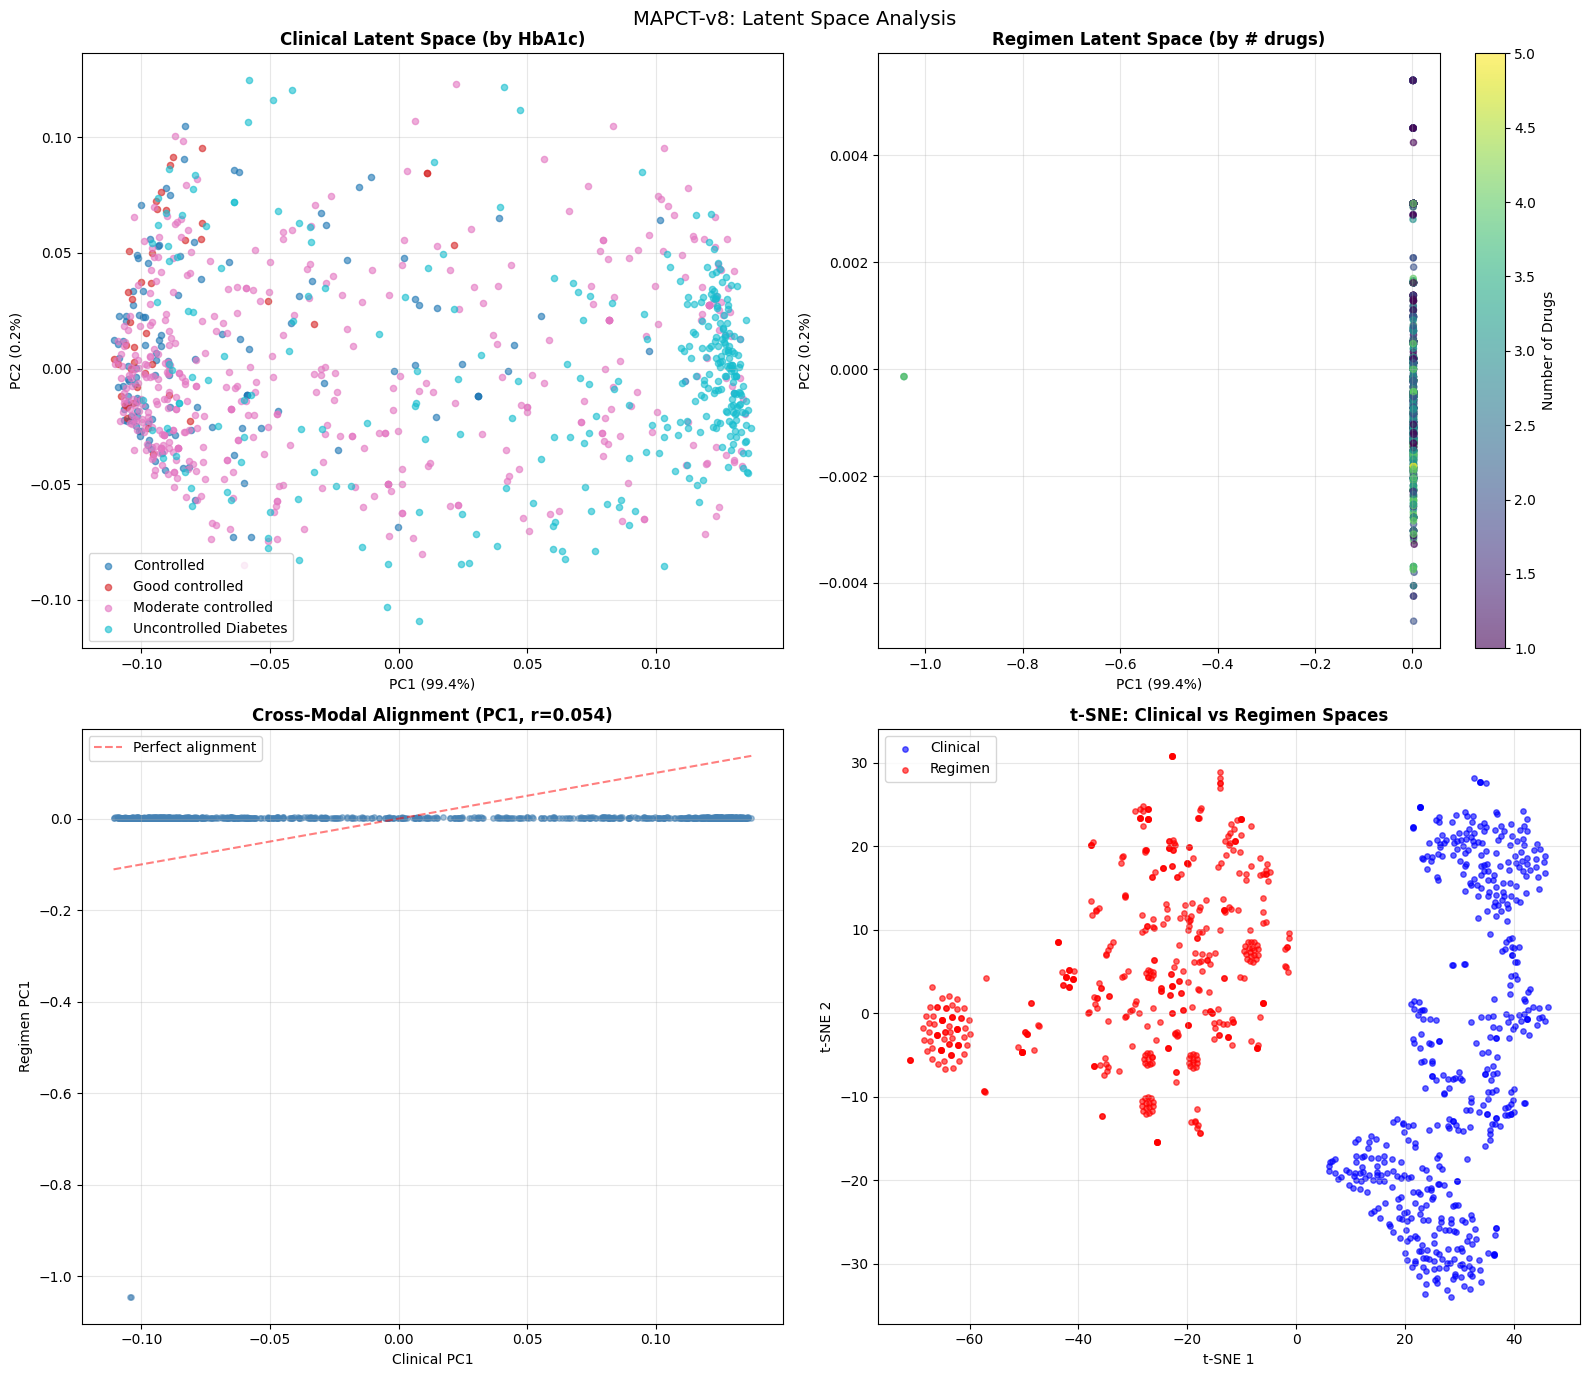


🎨 Creating drug prediction visualizations...


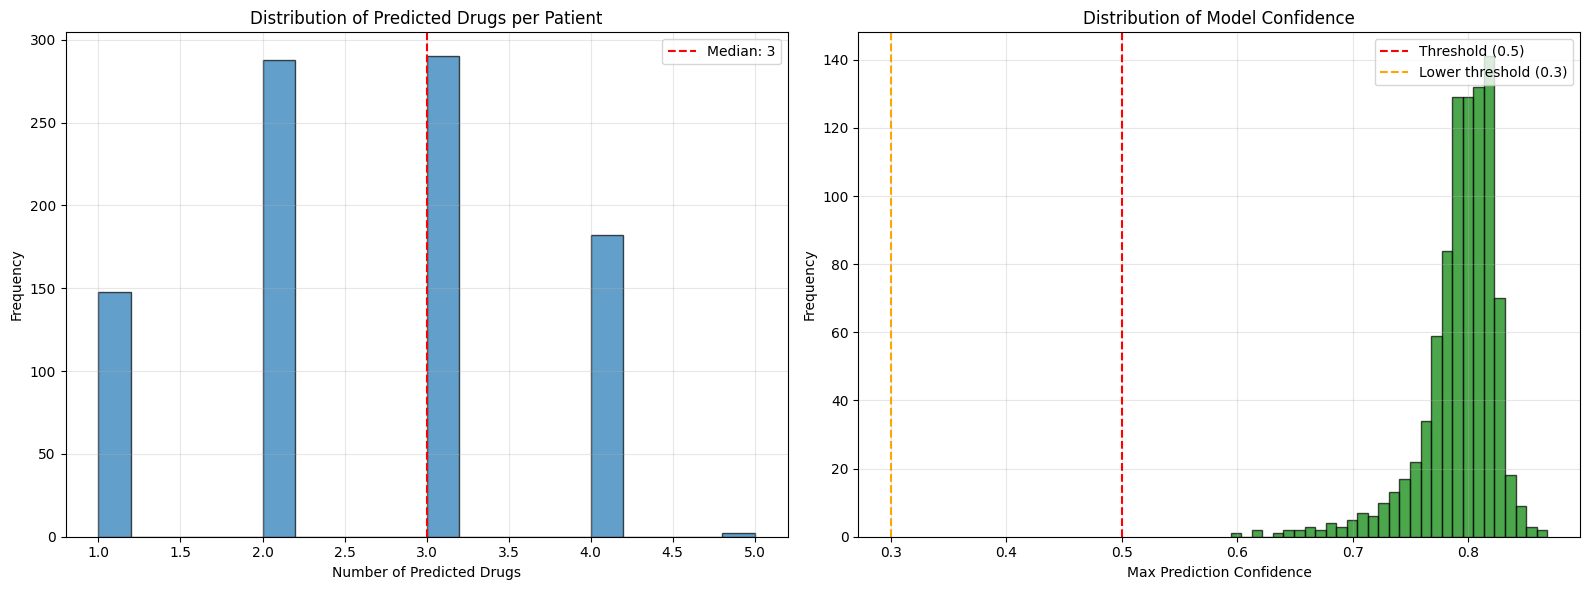


🎨 Computing flow likelihood distribution...


Computing log-likelihoods: 100%|██████████| 15/15 [00:00<00:00, 31.09it/s]


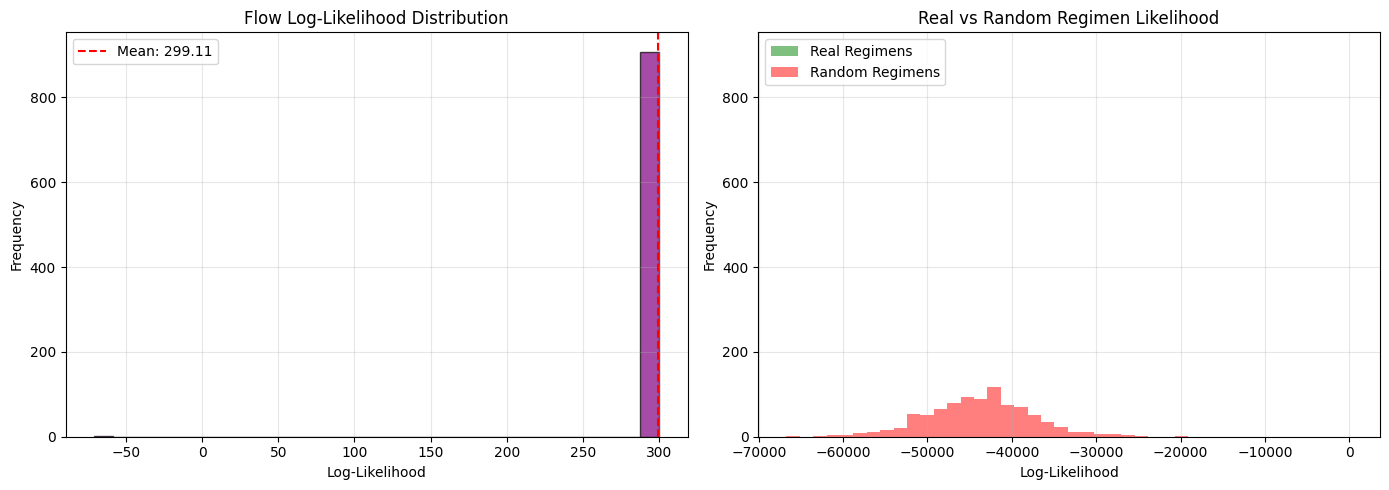


📊 Log-likelihood statistics:
   Real regimens:   mean=299.11, std=17.36
   Random regimens: mean=-43847.76, std=6134.55
   Difference: 44146.87

🎨 Creating example patient analysis...


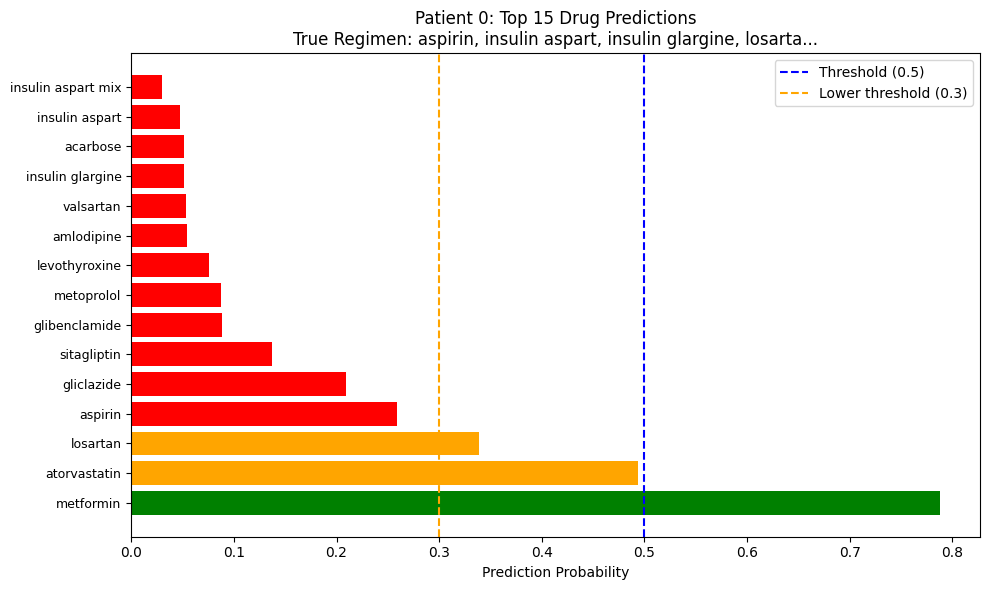

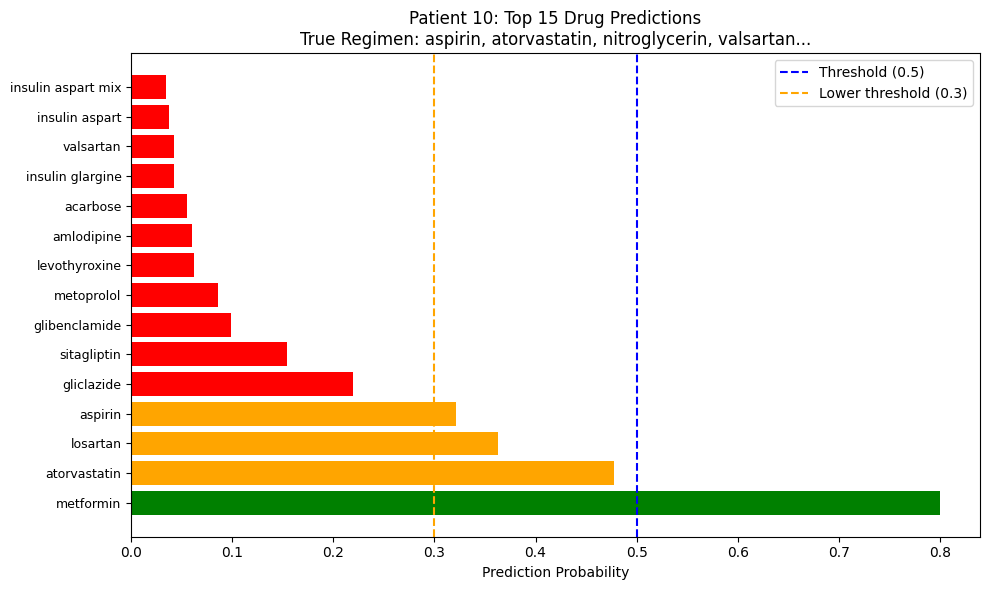

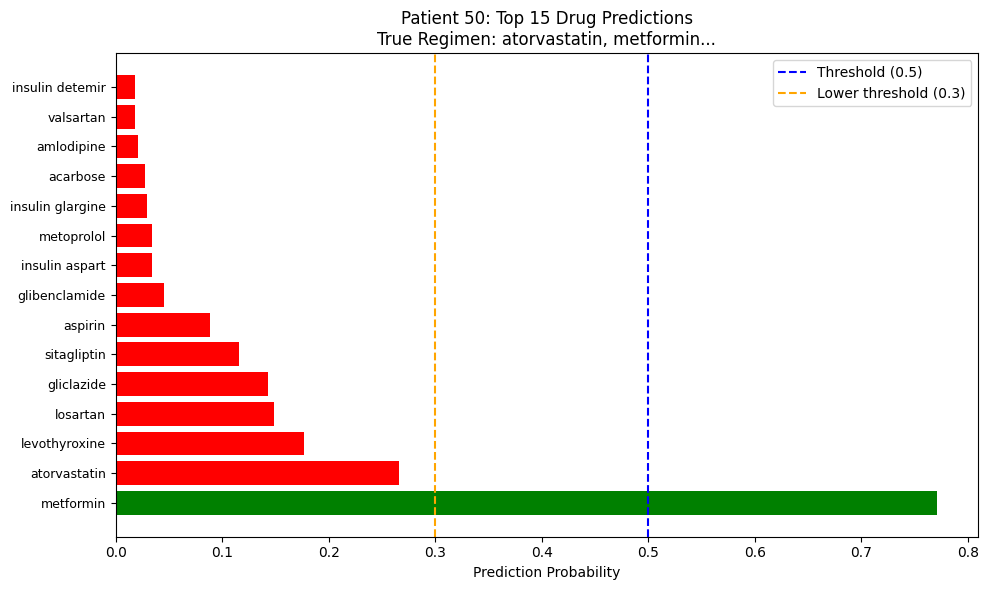


🗺️ UMAP LATENT SPACE VISUALIZATION


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


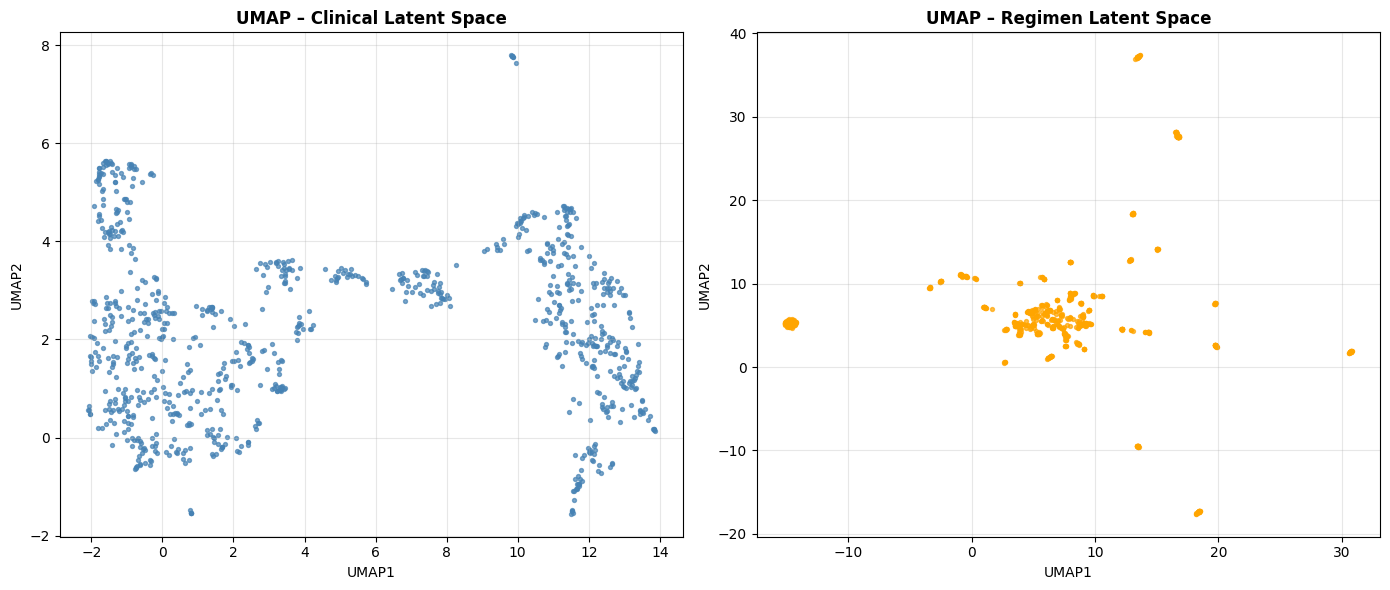

✅ UMAP visualisation complete.

📊 RUNNING COMPLETE EVALUATION

MAPCT‑v8 (Normalizing Flow) Test Evaluation
Threshold: 0.3
Precision (micro): 0.5519
Recall    (micro): 0.4813
F1‑score  (micro): 0.5142
Accuracy (overall): 0.9833
Clinical‑Drug Alignment (mean cosine): 0.2131
Generation Diversity (mean pairwise Jaccard distance): 0.4614

Evaluation results: {'precision': 0.5518867924528302, 'recall': 0.48130142109199703, 'f1': 0.5141829804234919, 'accuracy': 0.9832967032967033, 'alignment': np.float32(0.21305789), 'diversity': np.float64(0.4613632765191427)}

📊 COMPLETE METRICS FOR MAPCT‑v8

🎯 Drug Prediction (threshold=0.3):
   Precision: 0.5519
   Recall:    0.4813
   F1-Score:  0.5142
   Accuracy:  0.9833

🔗 Clinical–Regimen Alignment:
   Mean cosine: 0.2131

🎨 Generation Diversity:
   Mean Jaccard distance: 0.4614

✅ Metrics saved to 'mapct_v8_metrics.json'

👥 PATIENT-LEVEL ANALYSIS

PATIENT 1 (Test index: 0)

📊 CLINICAL PROFILE:
   Age: 67.0
   Sex: Male
   HbA1c: 7.7 (Diabetes)

💊 AC

AttributeError: 'MAPCTv8Trainer' object has no attribute 'model'

In [ ]:

# ============================================================
# SECTION 17: MAIN EXECUTION (UPDATED WITH VISUALIZATIONS)
# ============================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("🚀 MAPCT-v8: NORMALIZING FLOW FOR REGIMEN GENERATION")
    print("="*70)

    # Run the complete pipeline (training + basic evaluation)
    trainer, history, metrics = run_mapct_v8_pipeline()

    # ============================================================
    # ADD THIS: Post-training visualizations
    # ============================================================
    print("\n" + "="*70)
    print("🎨 GENERATING COMPREHENSIVE VISUALIZATIONS")
    print("="*70)

    viz_results = create_visualization_dashboard(
        trainer=trainer,
        test_loader=test_loader,
        test_df=test_df,
        X_test=X_test,
        idx_to_drug=idx_to_drug,
        drug_embeddings=drug_embeddings,
        device=device,
        batch_size=BATCH_SIZE
    )

    # ============================================================
    # ADD UMAP VISUALISATION
    # ============================================================
    print("\n" + "="*70)
    print("🗺️ UMAP LATENT SPACE VISUALIZATION")
    print("="*70)

    try:
        import umap
        from sklearn.preprocessing import StandardScaler

        # Collect clinical and regimen latents from test set
        trainer.clinical_encoder.eval()
        trainer.regimen_encoder.eval()

        z_clin_list = []
        z_reg_list = []

        with torch.no_grad():
            for batch in test_loader:
                clinical = batch['clinical'].to(device)
                mech_tensor = batch['mech_tensor'].to(device)
                mech_mask = batch['mech_mask'].to(device)

                zc = trainer.clinical_encoder(clinical).cpu().numpy()
                zr = trainer.regimen_encoder(mech_tensor, mech_mask).cpu().numpy()

                z_clin_list.append(zc)
                z_reg_list.append(zr)

        Z_clin = np.vstack(z_clin_list)
        Z_reg = np.vstack(z_reg_list)

        # UMAP
        reducer = umap.UMAP(random_state=SEED, n_components=2)
        Z_clin_umap = reducer.fit_transform(Z_clin)
        Z_reg_umap = reducer.fit_transform(Z_reg)

        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].scatter(Z_clin_umap[:,0], Z_clin_umap[:,1], s=8, alpha=0.7, c='steelblue')
        axes[0].set_title("UMAP – Clinical Latent Space", fontsize=12, fontweight='bold')
        axes[0].set_xlabel("UMAP1")
        axes[0].set_ylabel("UMAP2")
        axes[0].grid(True, alpha=0.3)

        axes[1].scatter(Z_reg_umap[:,0], Z_reg_umap[:,1], s=8, alpha=0.7, c='orange')
        axes[1].set_title("UMAP – Regimen Latent Space", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("UMAP1")
        axes[1].set_ylabel("UMAP2")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("✅ UMAP visualisation complete.")

    except ImportError:
        print("⚠️ UMAP not installed. Skipping UMAP plots. Install with: !pip install umap-learn")


    # ============================================================
    # FULL EVALUATION (precision, recall, F1, accuracy, alignment, diversity)
    # ============================================================
    print("\n" + "="*70)
    print("📊 RUNNING COMPLETE EVALUATION")
    print("="*70)

    results_v8 = evaluate_mapct_v8(
        trainer=trainer,
        test_loader=test_loader,
        drug_vocab=drug_vocab,
        idx_to_drug=idx_to_drug,
        device=device,
        threshold=0.3,
        num_stochastic=5
    )
    print("\nEvaluation results:", results_v8)

    for i in range(3):
    inspect_patient_metabolic_profile(
        patient_idx=i,
        model=trainer,                   # MAPCTv8Trainer instance
        device=device,
        test_df=test_df,
        clinical_preprocessor=clinical_preprocessor,  # you have this in v8 script
        drug_vocab=drug_vocab,
        idx_to_drug=idx_to_drug,
        drug_embeddings=drug_embeddings,
        drug_to_idx=drug_to_idx,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        threshold=0.3,
        use_regimen_encoder=True
    )

    # ============================================================
    # COMPREHENSIVE METRICS (same as before)
    # ============================================================
    print("\n" + "="*60)
    print("📊 COMPLETE METRICS FOR MAPCT‑v8")
    print("="*60)

    print(f"\n🎯 Drug Prediction (threshold=0.3):")
    print(f"   Precision: {results_v8['precision']:.4f}")
    print(f"   Recall:    {results_v8['recall']:.4f}")
    print(f"   F1-Score:  {results_v8['f1']:.4f}")
    print(f"   Accuracy:  {results_v8['accuracy']:.4f}")

    print(f"\n🔗 Clinical–Regimen Alignment:")
    print(f"   Mean cosine: {results_v8['alignment']:.4f}")

    print(f"\n🎨 Generation Diversity:")
    print(f"   Mean Jaccard distance: {results_v8['diversity']:.4f}")

    # Save metrics (JSON serialisation fix)
    import json
    def convert_to_serializable(obj):
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [convert_to_serializable(i) for i in obj]
        return obj

    results_serializable = convert_to_serializable(results_v8)
    with open('mapct_v8_metrics.json', 'w') as f:
        json.dump(results_serializable, f, indent=2)
    print("\n✅ Metrics saved to 'mapct_v8_metrics.json'")

    # ============================================================
    # DETAILED PATIENT METABOLIC PROFILE (using new unified function)
    # ============================================================
    print("\n" + "="*60)
    print("👥 PATIENT-LEVEL METABOLIC ANALYSIS (First 3 test patients)")
    print("="*60)

    # Make sure the inspect function is defined somewhere above (paste it before main)
    for i in range(min(3, len(test_df))):
        inspect_patient_metabolic_profile(
            patient_idx=i,
            model=trainer,                    # trainer has .clinical_encoder etc.
            device=device,
            test_df=test_df,
            clinical_preprocessor=clinical_preprocessor,  # you already have this
            drug_vocab=drug_vocab,
            idx_to_drug=idx_to_drug,
            drug_embeddings=drug_embeddings,
            drug_to_idx=drug_to_idx,
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            threshold=0.3,
            use_regimen_encoder=True          # v8 uses regimen_encoder
        )

    # ============================================================
    # SAVE FINAL MODEL (using the trainer's method)
    # ============================================================
    save_choice = input("\n💾 Save final model? (y/n, default=n): ").strip().lower()
    if save_choice == 'y':
        trainer.save_checkpoint('mapct_v8_final.pt')
        print("✅ Final model saved to mapct_v8_final.pt")
    else:
        print("ℹ️ Model not saved.")

    print("\n" + "="*60)
    print("✅ MAPCT-v8 COMPLETE!")
    print(f"   Test F1: {results_v8['f1']:.4f}")
    print(f"   Clinical-Regimen Alignment: {results_v8['alignment']:.4f}")
    print(f"   Generation Diversity: {results_v8['diversity']:.4f}")
    print("="*60)

    # Collect latents from test set
    Z_clin, Z_reg = collect_latents_v8(trainer, test_loader, device)

    # After collecting Z_clin, Z_reg (from collect_latents_v8 or compute_test_latents)
    # ========== JOINT PCA ==========
    Z_joint = np.vstack([Z_clin, Z_reg])
    pca = PCA(n_components=2, random_state=42)
    Z_joint_pca = pca.fit_transform(Z_joint)
    n_clin = len(Z_clin)
    Z_clin_pca = Z_joint_pca[:n_clin]
    Z_reg_pca = Z_joint_pca[n_clin:]

    plt.figure(figsize=(10, 8))
    plt.scatter(Z_clin_pca[:, 0], Z_clin_pca[:, 1], marker='o', s=30, alpha=0.6, c='blue', label='Clinical')
    plt.scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], marker='s', s=30, alpha=0.6, c='red', label='Regimen')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('Joint PCA: Clinical vs Regimen Latent Spaces')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('v8_joint_pca.png', dpi=150)
    plt.show()

    # ========== JOINT UMAP (if available) ==========
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(random_state=42, n_components=2)
        Z_joint_umap = reducer.fit_transform(Z_joint)
        Z_clin_umap = Z_joint_umap[:n_clin]
        Z_reg_umap = Z_joint_umap[n_clin:]

        plt.figure(figsize=(10, 8))
        plt.scatter(Z_clin_umap[:, 0], Z_clin_umap[:, 1], marker='o', s=30, alpha=0.6, c='blue', label='Clinical')
        plt.scatter(Z_reg_umap[:, 0], Z_reg_umap[:, 1], marker='s', s=30, alpha=0.6, c='red', label='Regimen')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.title('Joint UMAP: Clinical vs Regimen Latent Spaces')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('v8_joint_umap.png', dpi=150)
        plt.show()
    else:
        print("UMAP not installed – skipping joint UMAP plot.")

    # PCA plots (separate)
    plot_pca_latent_spaces(Z_clin, Z_reg, test_df=test_df, save_path='v8_pca.png')

    # Joint t‑SNE (clinical + regimen in same plot)
    plot_joint_tsne(Z_clin, Z_reg, test_df=test_df, perplexity=30, save_path='v8_joint_tsne.png')

    # UMAP (separate, optional)
    plot_umap_latent_spaces(Z_clin, Z_reg, test_df=test_df, save_path='v8_umap.png')

    # Run interactive demo
    print("\n" + "="*70)
    print("🎮 LAUNCHING INTERACTIVE DEMO")
    print("="*70)

    interactive_flow_demo(
        trainer=trainer,
        scaler=scaler,
        ohe=ohe,
        drug_vocab=drug_vocab,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        device=device
    )

    # Optional: Run patient inspector
    run_inspector = input("\n🔍 Run patient inspector? (y/n, default=n): ").strip().lower()
    if run_inspector == 'y':
        while True:
            try:
                idx = int(input("\nEnter patient index (or -1 to exit): "))
                if idx == -1:
                    break
                if idx < 0 or idx >= len(test_df):
                    print("Index out of range.")
                    continue

                inspect_patient(
                    patient_idx=idx,
                    df=test_df,
                    clinical_features=X_test,
                    scaler=scaler,
                    ohe=ohe,
                    trainer=trainer,
                    drug_to_idx=drug_to_idx,
                    idx_to_drug=idx_to_drug,
                    drug_embeddings=drug_embeddings,
                    numeric_cols=numeric_cols,
                    categorical_cols=categorical_cols,
                    top_k=5
                )
            except ValueError:
                print("Invalid input. Please enter a number.")

    print("\n" + "="*70)
    print("✅ MAPCT-v8 COMPLETE!")
    print("="*70)